In [1]:
import os
import glob
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


//gemini CNN LSTM FOR BANDPASS FILTERED DATA

In [68]:
import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, confusion_matrix

# TensorFlow/Keras imports
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. CONFIGURATION AND DATA PATHS ---
print("TensorFlow version:", tf.__version__)

# !!! CRITICAL: SET THIS PATH TO YOUR DATA FOLDER (e.g., /1_BandPass_Filtered OR /2_ATAR_Artifact_Removed) !!!
DATA_FOLDER = "/Users/csuftitan/Documents/LieWaves.dataset/Preprocessing/1_BandPass_Filtered" 
META_PATH = "/Users/csuftitan/Documents/LieWaves.dataset/Subject_Stimuli.xlsx"

# Segmentation Parameters (128 Hz sampling rate)
WINDOW_SIZE = 128   # 1.0 second window
STEP = 128          # 1.0 second step (NO OVERLAP)
TEST_SIZE_GROUPS = 0.2
RANDOM_SEED = 42

# --- 2. HELPER FUNCTIONS ---

def get_session_label(subject, session, meta_df):
    """Maps metadata's 1 (TRUTH)/0 (LIE) to model's 0 (TRUTH)/1 (LIE)."""
    row = meta_df[(meta_df['SUBJECT'] == subject) & (meta_df['SESSION'] == session)]
    if row.empty:
        raise ValueError(f"No metadata found for subject={subject}, session={session}")
    val = int(row['LIE/TRUTH'].iloc[0])
    # Convert meta's convention (1=Truth, 0=Lie) to model's convention (0=Truth, 1=Lie)
    return 0 if val == 1 else 1  

def parse_subject_session(filename):
    """Parses subject and session strings from the filename (e.g., 'S10S1.csv')."""
    base = os.path.basename(filename).replace(".csv", "")
    subject = base[:-2]       
    session = base[-2:]       
    return subject, session

def segment_signal(data, window_size=WINDOW_SIZE, step=STEP):
    """Segments the continuous data into fixed-size windows."""
    segments = []
    for start in range(0, len(data) - window_size + 1, step):
        segments.append(data[start:start+window_size])
    return np.array(segments)

def normalize_segments(segments):
    """Normalizes each segment/channel using StandardScaler (Z-score)."""
    normalized = []
    for seg in segments:
        scaler = StandardScaler()
        # Input shape: (time_points, channels)
        seg_norm = scaler.fit_transform(seg) 
        normalized.append(seg_norm)
    return np.array(normalized)

# --- 3. DATA LOADING AND PREPROCESSING EXECUTION ---
print("\n--- Data Loading and Preprocessing ---")
meta = pd.read_excel(META_PATH)
all_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "S*S*.csv")))
print(f"Loading data from: {DATA_FOLDER}")

X_list = []
y_list = []
subjects_list = []

for path in all_files:
    subject, session = parse_subject_session(path)
    try:
        label = get_session_label(subject, session, meta)
    except ValueError:
        continue # Skip if metadata is missing
        
    df = pd.read_csv(path)
    data = df.values  # shape (time_points, channels)
    
    # 3.1 SEGMENTATION
    segments = segment_signal(data)
    if len(segments) == 0:
        continue
    
    # 3.2 NORMALIZATION (StandardScaler/Z-score)
    segments_norm = normalize_segments(segments) 
    
    labels = np.full(len(segments_norm), label, dtype=int)
    
    # Collect results
    X_list.append(segments_norm)
    y_list.append(labels)
    subjects_list.extend([subject] * len(segments_norm))

X_all = np.vstack(X_list)
y_all = np.concatenate(y_list)
subjects_all = np.array(subjects_list)

print(f"X_all shape (Total segments, Time steps, Channels): {X_all.shape}")
print(f"y_all shape: {y_all.shape}")
print(f"Unique subjects: {len(np.unique(subjects_all))}")
print(f"Label counts (0=Truth, 1=Lie): {np.bincount(y_all)}")

# --- 4. SUBJECT-WISE TRAIN/TEST SPLIT ---
print("\n--- Subject-Wise Split (GroupShuffleSplit) ---")
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE_GROUPS, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=subjects_all))

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

print(f"Train X shape: {X_train.shape}")
print(f"Test X shape : {X_test.shape}")
print(f"Test subjects: {np.unique(subjects_all[test_idx])}")

# --- 5. MODEL DEFINITION (CNN-LSTM Architecture) ---

def create_cnn_lstm(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    
    # CNN Layers (Feature Extraction)
    model.add(Conv1D(32, 3, activation='relu'))
    model.add(MaxPooling1D(2))
    model.add(Conv1D(64, 3, activation='relu'))
    model.add(MaxPooling1D(2))
    model.add(Dropout(0.25))
    
    # LSTM Layer (Temporal Modeling)
    model.add(LSTM(32))
    model.add(Dropout(0.5))
    
    # Output Layer
    model.add(Dense(1, activation='sigmoid'))
    return model

input_shape = (X_train.shape[1], X_train.shape[2])
model = create_cnn_lstm(input_shape)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

# --- 6. TRAINING WITH EARLY STOPPING ---
print("\n--- Model Training with Early Stopping ---")

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=15, # Allows training to continue for 15 epochs without improvement
    restore_best_weights=True, 
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=100, # Max epochs, but EarlyStopping will intervene
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

# --- 7. FINAL EVALUATION ---
print("\n--- Final Evaluation on Test Set ---")

test_loss, test_acc, test_prec, test_rec = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int)

test_f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test Precision : {test_prec:.4f}")
print(f"Test Recall    : {test_rec:.4f}")
print(f"Test F1 Score  : {test_f1:.4f}")
print("\nConfusion Matrix (Actual vs. Predicted):\n", cm)
print("[[True Negatives, False Positives]\n [False Negatives, True Positives]]")

TensorFlow version: 2.20.0

--- Data Loading and Preprocessing ---
Meta shape: (54, 8), Files found: 54
X_all shape (Total segments, Time steps, Channels): (4050, 128, 5)
y_all shape: (4050,)
Unique subjects: 27
Label counts (0=Truth, 1=Lie): [2025 2025]

--- Subject-Wise Split (GroupShuffleSplit) ---
Train X shape: (3150, 128, 5)
Test X shape : (900, 128, 5)
Test subjects: ['S1' 'S17' 'S18' 'S2' 'S21' 'S4']

--- Model Training with Early Stopping ---
Epoch 1/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5054 - loss: 0.7017 - precision: 0.5055 - recall: 0.4971 - val_accuracy: 0.5178 - val_loss: 0.6919 - val_precision: 0.5533 - val_recall: 0.1844
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5079 - loss: 0.6966 - precision: 0.5080 - recall: 0.5060 - val_accuracy: 0.5278 - val_loss: 0.6922 - val_precision: 0.5451 - val_recall: 0.3356
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5286 - loss: 0.6928 - precision: 0.5321 - recall: 0.4743 - v

gemini CNN-LSTM MODEL FOR ATAR MODEL 

In [74]:
import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. CONFIGURATION AND DATA PATHS ---
print("TensorFlow version:", tf.__version__)

# !!! CRITICAL FOR YOUR EXPERIMENT: CHANGE THIS PATH !!!
# Path A (Current BPF Data):
# DATA_FOLDER = "/Users/csuftitan/Documents/LieWaves.dataset/Preprocessing/1_BandPass_Filtered"
# Path B (Hypothetical ATAR Data):
DATA_FOLDER = "/Users/csuftitan/Documents/LieWaves.dataset//Preprocessing/4_ATAR" 

META_PATH = "/Users/csuftitan/Documents/LieWaves.dataset/Subject_Stimuli.xlsx"

# Segmentation Parameters
WINDOW_SIZE = 128  # 1.0 second window
STEP = 128         # Non-overlapping step
TEST_SIZE_GROUPS = 0.2
RANDOM_SEED = 42

# --- 2. HELPER FUNCTIONS (KEEPING NORMALIZATION) ---

def get_session_label(subject, session, meta_df):
    """Maps metadata's 1/0 (Truth/Lie) to model's 0/1 (Truth/Lie)."""
    row = meta_df[(meta_df['SUBJECT'] == subject) & (meta_df['SESSION'] == session)]
    if row.empty:
        raise ValueError(f"No metadata found for subject={subject}, session={session}")
    val = int(row['LIE/TRUTH'].iloc[0])
    return 0 if val == 1 else 1 # 0=Truth, 1=Lie

def parse_subject_session(filename):
    """Parses subject and session strings from the filename (e.g., 'S10S1.csv')."""
    base = os.path.basename(filename).replace(".csv", "")
    subject = base[:-2]      
    session = base[-2:]      
    return subject, session

def segment_signal(data, window_size=WINDOW_SIZE, step=STEP):
    """Segments the continuous data into fixed-size windows."""
    segments = []
    for start in range(0, len(data) - window_size + 1, step):
        segments.append(data[start:start+window_size])
    return np.array(segments)

def normalize_segments(segments):
    """Normalizes each segment/channel using StandardScaler (Z-score)."""
    normalized = []
    for seg in segments:
        scaler = StandardScaler()
        # Input shape: (time_points, channels)
        seg_norm = scaler.fit_transform(seg) 
        normalized.append(seg_norm)
    return np.array(normalized)

# --- 3. DATA LOADING AND PREPROCESSING EXECUTION ---
print("\n--- Data Loading and Preprocessing ---")
meta = pd.read_excel(META_PATH)
all_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "S*S*.csv")))
print(f"Loading data from: {DATA_FOLDER}")

X_list = []
y_list = []
subjects_list = []

for path in all_files:
    subject, session = parse_subject_session(path)
    try:
        label = get_session_label(subject, session, meta)
    except ValueError:
        continue
        
    df = pd.read_csv(path)
    data = df.values  # shape (time_points, channels)
    segments = segment_signal(data)
    if len(segments) == 0:
        continue
    
    # Step 1: Segmentation is done. Step 2: Normalization is done.
    segments_norm = normalize_segments(segments) 
    
    labels = np.full(len(segments_norm), label, dtype=int)
    
    X_list.append(segments_norm)
    y_list.append(labels)
    subjects_list.extend([subject] * len(segments_norm))

X_all = np.vstack(X_list)
y_all = np.concatenate(y_list)
subjects_all = np.array(subjects_list)

print(f"Total Segments Loaded: {X_all.shape[0]}")
print(f"Label counts (0=Truth, 1=Lie): {np.bincount(y_all)}")

# --- 4. SUBJECT-WISE TRAIN/TEST SPLIT ---
print("\n--- Subject-Wise Split (GroupShuffleSplit) ---")
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE_GROUPS, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=subjects_all))

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

print(f"Train X shape: {X_train.shape}")
print(f"Test X shape : {X_test.shape}")
print(f"Test subjects: {np.unique(subjects_all[test_idx])}")

# --- 5. MODEL DEFINITION ---

def create_cnn_lstm(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    
    # CNN Layers (Feature Extraction)
    model.add(Conv1D(32, 3, activation='relu'))
    model.add(MaxPooling1D(2))
    model.add(Conv1D(64, 3, activation='relu'))
    model.add(MaxPooling1D(2))
    model.add(Dropout(0.25))
    
    # LSTM Layer (Temporal Modeling)
    model.add(LSTM(32))
    model.add(Dropout(0.5))
    
    # Output Layer
    model.add(Dense(1, activation='sigmoid'))
    return model

input_shape = (X_train.shape[1], X_train.shape[2])
model = create_cnn_lstm(input_shape)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)
print("Model compiled successfully.")

# --- 6. TRAINING AND EVALUATION ---
print("\n--- Model Training ---")

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True, 
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=100, 
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

print("\n--- Final Evaluation on Test Set ---")

test_loss, test_acc, test_prec, test_rec = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int)

test_f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test F1 Score  : {test_f1:.4f}")
print("\nConfusion Matrix (Actual vs. Predicted):\n", cm)
print("[[True Negatives, False Positives]\n [False Negatives, True Positives]]")

TensorFlow version: 2.20.0

--- Data Loading and Preprocessing ---
Loading data from: /Users/csuftitan/Documents/LieWaves.dataset//Preprocessing/4_ATAR
Total Segments Loaded: 4050
Label counts (0=Truth, 1=Lie): [2025 2025]

--- Subject-Wise Split (GroupShuffleSplit) ---
Train X shape: (3150, 128, 5)
Test X shape : (900, 128, 5)
Test subjects: ['S1' 'S17' 'S18' 'S2' 'S21' 'S4']
Model compiled successfully.

--- Model Training ---
Epoch 1/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5035 - loss: 0.7000 - precision: 0.5034 - recall: 0.5156 - val_accuracy: 0.5178 - val_loss: 0.6916 - val_precision: 0.6026 - val_recall: 0.1044
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5216 - loss: 0.6931 - precision: 0.5237 - recall: 0.4768 - val_accuracy: 0.4911 - val_loss: 0.6939 - val_precision: 0.4949 - val_recall: 0.8600
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5260 - loss: 0.6918 - precision: 0.5236 - recall: 0.5784 - val_accuracy: 0.5278 - 

using FFT

In [75]:
import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, confusion_matrix

# TensorFlow/Keras imports
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. CONFIGURATION AND DATA PATHS ---
print("TensorFlow version:", tf.__version__)

# !!! CRITICAL: SET THIS PATH TO YOUR ATAR-CLEANED DATA FOLDER !!!
DATA_FOLDER = "/Users/csuftitan/Documents/LieWaves.dataset/Preprocessing/4_ATAR" 
META_PATH = "/Users/csuftitan/Documents/LieWaves.dataset/Subject_Stimuli.xlsx"

# Segmentation Parameters (128 Hz sampling rate)
WINDOW_SIZE = 128
STEP = 128
FS = 128 # Sampling Frequency

# Frequency Bands (Hz) for Feature Extraction
# Standard bands used in cognitive research:
BANDS = {
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30)
}

TEST_SIZE_GROUPS = 0.2
RANDOM_SEED = 42

# --- 2. HELPER FUNCTIONS (Including new FFT function) ---

def get_session_label(subject, session, meta_df):
    """Maps metadata's 1 (TRUTH)/0 (LIE) to model's 0 (TRUTH)/1 (LIE)."""
    row = meta_df[(meta_df['SUBJECT'] == subject) & (meta_df['SESSION'] == session)]
    if row.empty:
        raise ValueError(f"No metadata found for subject={subject}, session={session}")
    val = int(row['LIE/TRUTH'].iloc[0])
    return 0 if val == 1 else 1  

def parse_subject_session(filename):
    """Parses subject and session strings from the filename."""
    base = os.path.basename(filename).replace(".csv", "")
    subject = base[:-2]       
    session = base[-2:]       
    return subject, session

def segment_signal(data, window_size=WINDOW_SIZE, step=STEP):
    """Segments the continuous data into fixed-size windows."""
    segments = []
    for start in range(0, len(data) - window_size + 1, step):
        segments.append(data[start:start+window_size])
    return np.array(segments)

def normalize_segments(segments):
    """Normalizes each segment/channel using StandardScaler (Z-score)."""
    normalized = []
    for seg in segments:
        scaler = StandardScaler()
        seg_norm = scaler.fit_transform(seg) 
        normalized.append(seg_norm)
    return np.array(normalized)

def extract_band_power(segment, fs=FS, bands=BANDS):
    """
    Applies FFT to the segment and extracts the average power for defined frequency bands.
    
    Args:
        segment: A single EEG segment (Time steps, Channels).
    Returns:
        A flattened feature vector (Channels * Bands).
    """
    # 1. Apply FFT to the time domain signal
    fft_result = np.fft.fft(segment, axis=0)
    # Power Spectral Density (PSD) is proportional to the square of the magnitude
    psd = np.abs(fft_result)**2
    # Only take the first half (up to the Nyquist frequency)
    psd = psd[:len(psd)//2]
    frequencies = np.fft.fftfreq(len(segment), 1/fs)[:len(segment)//2]

    features = []
    # 2. Extract mean power for each band, for each of the 5 channels
    for ch in range(segment.shape[1]):
        for name, (fmin, fmax) in bands.items():
            # Find the indices corresponding to the frequency band
            idx_band = np.where((frequencies >= fmin) & (frequencies <= fmax))
            # Calculate the mean power in that band for that channel
            band_power = np.mean(psd[idx_band, ch])
            features.append(band_power)
            
    return np.array(features)

# --- 3. DATA LOADING AND FEATURE EXTRACTION EXECUTION ---
print("\n--- Data Loading and FFT Feature Extraction ---")
meta = pd.read_excel(META_PATH)
all_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "S*S*.csv")))
print(f"Loading data from: {DATA_FOLDER}")

X_list = []
y_list = []
subjects_list = []

for path in all_files:
    subject, session = parse_subject_session(path)
    try:
        label = get_session_label(subject, session, meta)
    except ValueError:
        continue
        
    df = pd.read_csv(path)
    data = df.values  # shape (time_points, channels)
    segments = segment_signal(data)
    
    if len(segments) == 0: continue
    
    segments_norm = normalize_segments(segments) 
    
    # NEW STEP: FFT Feature Extraction
    for seg_norm in segments_norm:
        features = extract_band_power(seg_norm)
        X_list.append(features)
        y_list.append(label)
        subjects_list.append(subject) # Subject ID for each segment

X_all = np.array(X_list)
y_all = np.array(y_list)
subjects_all = np.array(subjects_list)

# The new shape is (Total segments, Channels * Bands)
print(f"X_all shape (Total segments, Extracted Features): {X_all.shape}") 
print(f"Total Features per Segment (5 channels * 3 bands): {X_all.shape[1]}")
print(f"Label counts (0=Truth, 1=Lie): {np.bincount(y_all)}")
# 

# --- 4. SUBJECT-WISE TRAIN/TEST SPLIT ---
print("\n--- Subject-Wise Split (GroupShuffleSplit) ---")
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE_GROUPS, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=subjects_all))

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

print(f"Train X shape: {X_train.shape}")
print(f"Test X shape : {X_test.shape}")
print(f"Test subjects: {np.unique(subjects_all[test_idx])}")

# --- 5. MODEL DEFINITION (Simple Dense Network / MLP) ---

def create_dense_network(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    return model

input_shape = (X_train.shape[1],) # Note: The input is now 1D feature vector
model = create_dense_network(input_shape)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)
print("Dense Model compiled successfully.")

# --- 6. TRAINING WITH EARLY STOPPING ---
print("\n--- Model Training with Early Stopping ---")

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True, 
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=100, 
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

# --- 7. FINAL EVALUATION ---
print("\n--- Final Evaluation on Test Set (FFT Features) ---")

test_loss, test_acc, test_prec, test_rec = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int)

test_f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test Precision : {test_prec:.4f}")
print(f"Test Recall    : {test_rec:.4f}")
print(f"Test F1 Score  : {test_f1:.4f}")
print("\nConfusion Matrix (Actual vs. Predicted):\n", cm)
print("[[True Negatives, False Positives]\n [False Negatives, True Positives]]")

TensorFlow version: 2.20.0

--- Data Loading and FFT Feature Extraction ---
Loading data from: /Users/csuftitan/Documents/LieWaves.dataset/Preprocessing/4_ATAR
X_all shape (Total segments, Extracted Features): (4050, 15)
Total Features per Segment (5 channels * 3 bands): 15
Label counts (0=Truth, 1=Lie): [2025 2025]

--- Subject-Wise Split (GroupShuffleSplit) ---
Train X shape: (3150, 15)
Test X shape : (900, 15)
Test subjects: ['S1' 'S17' 'S18' 'S2' 'S21' 'S4']
Dense Model compiled successfully.

--- Model Training with Early Stopping ---
Epoch 1/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5086 - loss: 50.7223 - precision: 0.5094 - recall: 0.4654 - val_accuracy: 0.4900 - val_loss: 6.4714 - val_precision: 0.4946 - val_recall: 0.9133
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4838 - loss: 13.2347 - precision: 0.4836 - recall: 0.4787 - val_accuracy: 0.5067 - val_loss: 1.1416 - val_precision: 0.5035 - val_recall: 0.9511
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━

fft with suisng standard scaler

In [76]:
import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, confusion_matrix

# TensorFlow/Keras imports
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. CONFIGURATION AND DATA PATHS ---
print("TensorFlow version:", tf.__version__)

# Using the ATAR-cleaned data folder as planned
DATA_FOLDER = "/Users/csuftitan/Documents/LieWaves.dataset/Preprocessing/4_ATAR" 
META_PATH = "/Users/csuftitan/Documents/LieWaves.dataset/Subject_Stimuli.xlsx"

# Segmentation Parameters
WINDOW_SIZE = 128
STEP = 128
FS = 128 # Sampling Frequency

# Frequency Bands (Hz) for Feature Extraction
BANDS = {
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30)
}

TEST_SIZE_GROUPS = 0.2
RANDOM_SEED = 42

# --- 2. HELPER FUNCTIONS ---

def get_session_label(subject, session, meta_df):
    """Maps metadata's 1 (TRUTH)/0 (LIE) to model's 0 (TRUTH)/1 (LIE)."""
    row = meta_df[(meta_df['SUBJECT'] == subject) & (meta_df['SESSION'] == session)]
    if row.empty:
        raise ValueError(f"No metadata found for subject={subject}, session={session}")
    val = int(row['LIE/TRUTH'].iloc[0])
    return 0 if val == 1 else 1  

def parse_subject_session(filename):
    """Parses subject and session strings from the filename."""
    base = os.path.basename(filename).replace(".csv", "")
    subject = base[:-2]       
    session = base[-2:]       
    return subject, session

def segment_signal(data, window_size=WINDOW_SIZE, step=STEP):
    """Segments the continuous data into fixed-size windows."""
    segments = []
    for start in range(0, len(data) - window_size + 1, step):
        segments.append(data[start:start+window_size])
    return np.array(segments)

def normalize_segments_time_domain(segments):
    """Normalizes each segment/channel using StandardScaler (Z-score)."""
    normalized = []
    for seg in segments:
        scaler = StandardScaler()
        seg_norm = scaler.fit_transform(seg) 
        normalized.append(seg_norm)
    return np.array(normalized)

def extract_band_power(segment, fs=FS, bands=BANDS):
    """Applies FFT to the segment and extracts the average power for defined frequency bands."""
    
    # 1. Apply FFT
    fft_result = np.fft.fft(segment, axis=0)
    # Power Spectral Density (PSD)
    psd = np.abs(fft_result)**2
    # Only take the first half (up to the Nyquist frequency)
    psd = psd[:len(psd)//2]
    frequencies = np.fft.fftfreq(len(segment), 1/fs)[:len(segment)//2]

    features = []
    # 2. Extract mean power for each band, for each of the 5 channels
    for ch in range(segment.shape[1]):
        for name, (fmin, fmax) in bands.items():
            idx_band = np.where((frequencies >= fmin) & (frequencies <= fmax))
            band_power = np.mean(psd[idx_band, ch])
            features.append(band_power)
            
    return np.array(features)

# --- 3. DATA LOADING AND FEATURE EXTRACTION EXECUTION ---
print("\n--- Data Loading and FFT Feature Extraction ---")
meta = pd.read_excel(META_PATH)
all_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "S*S*.csv")))
print(f"Loading data from: {DATA_FOLDER}")

X_list = []
y_list = []
subjects_list = []

for path in all_files:
    subject, session = parse_subject_session(path)
    try:
        label = get_session_label(subject, session, meta)
    except ValueError:
        continue
        
    df = pd.read_csv(path)
    data = df.values
    segments = segment_signal(data)
    
    if len(segments) == 0: continue
    
    # Step 1: Time-Domain Normalization (Critical for FFT input quality)
    segments_norm = normalize_segments_time_domain(segments) 
    
    # Step 2: FFT Feature Extraction
    for seg_norm in segments_norm:
        features = extract_band_power(seg_norm)
        X_list.append(features)
        y_list.append(label)
        subjects_list.append(subject)

X_all = np.array(X_list)
y_all = np.array(y_list)
subjects_all = np.array(subjects_list)

print(f"Initial X_all shape (Total segments, Extracted Features): {X_all.shape}") 

# --- CRUCIAL STEP: POST-EXTRACTION FEATURE SCALING ---
print("\n--- Step 4: Post-Extraction Feature Scaling ---")
# Scale the features (the 15 PSD values) to have mean=0 and std=1 across all samples
scaler_features = StandardScaler()
X_all_scaled = scaler_features.fit_transform(X_all)
print("Features scaled successfully.")

# --- 4. SUBJECT-WISE TRAIN/TEST SPLIT ---
print("\n--- Subject-Wise Split (GroupShuffleSplit) ---")
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE_GROUPS, random_state=RANDOM_SEED)
# Use the SCALED features for the split
train_idx, test_idx = next(gss.split(X_all_scaled, y_all, groups=subjects_all))

X_train, X_test = X_all_scaled[train_idx], X_all_scaled[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

print(f"Train X shape: {X_train.shape}")
print(f"Test X shape : {X_test.shape}")
print(f"Test subjects: {np.unique(subjects_all[test_idx])}")

# --- 5. MODEL DEFINITION (Simple Dense Network / MLP) ---

def create_dense_network(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    return model

input_shape = (X_train.shape[1],) # Input shape is the number of features (15)
model = create_dense_network(input_shape)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)
print("Dense Model compiled successfully.")

# --- 6. TRAINING WITH EARLY STOPPING ---
print("\n--- Model Training with Early Stopping ---")

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True, 
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=100, 
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

# --- 7. FINAL EVALUATION ---
print("\n--- Final Evaluation on Test Set (FFT Features, Scaled) ---")

test_loss, test_acc, test_prec, test_rec = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int)

test_f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test Precision : {test_prec:.4f}")
print(f"Test Recall    : {test_rec:.4f}")
print(f"Test F1 Score  : {test_f1:.4f}")
print("\nConfusion Matrix (Actual vs. Predicted):\n", cm)
print("[[True Negatives, False Positives]\n [False Negatives, True Positives]]")

TensorFlow version: 2.20.0

--- Data Loading and FFT Feature Extraction ---
Loading data from: /Users/csuftitan/Documents/LieWaves.dataset/Preprocessing/4_ATAR
Initial X_all shape (Total segments, Extracted Features): (4050, 15)

--- Step 4: Post-Extraction Feature Scaling ---
Features scaled successfully.

--- Subject-Wise Split (GroupShuffleSplit) ---
Train X shape: (3150, 15)
Test X shape : (900, 15)
Test subjects: ['S1' 'S17' 'S18' 'S2' 'S21' 'S4']
Dense Model compiled successfully.

--- Model Training with Early Stopping ---
Epoch 1/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5038 - loss: 0.7392 - precision: 0.5038 - recall: 0.5092 - val_accuracy: 0.5222 - val_loss: 0.6970 - val_precision: 0.5211 - val_recall: 0.5489
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step - accuracy: 0.5137 - loss: 0.7119 - precision: 0.5143 - recall: 0.4908 - val_accuracy: 0.5256 - val_loss: 0.6943 - val_precision: 0.5235 - val_recall: 0.5689
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 89

//gemini with DWT 

In [77]:
import os
import glob
import numpy as np
import pandas as pd
import pywt # Library for Wavelet Transforms
import tensorflow as tf
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, confusion_matrix

# TensorFlow/Keras imports
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. CONFIGURATION AND DATA PATHS ---
print("TensorFlow version:", tf.__version__)
print("PyWavelets version:", pywt.__version__)

# !!! CRITICAL: SET THIS PATH TO YOUR ATAR-CLEANED DATA FOLDER !!!
DATA_FOLDER = "/Users/csuftitan/Documents/LieWaves.dataset/Preprocessing/4_ATAR" 
META_PATH = "/Users/csuftitan/Documents/LieWaves.dataset/Subject_Stimuli.xlsx"

# DWT Parameters
FS = 128 # Sampling Frequency
WAVELET = 'db4' # Daubechies 4 wavelet is common for EEG
# Decomposition levels to cover standard bands (128Hz / 2^L)
# Level 4: 4-8 Hz (Theta), Level 3: 8-16 Hz (Alpha/Beta), Level 2: 16-32 Hz (Beta)
LEVELS = 5 

TEST_SIZE_GROUPS = 0.2
RANDOM_SEED = 42

# --- 2. HELPER FUNCTIONS (Including new DWT function) ---

def get_session_label(subject, session, meta_df):
    """Maps metadata's 1 (TRUTH)/0 (LIE) to model's 0 (TRUTH)/1 (LIE)."""
    row = meta_df[(meta_df['SUBJECT'] == subject) & (meta_df['SESSION'] == session)]
    if row.empty:
        raise ValueError(f"No metadata found for subject={subject}, session={session}")
    val = int(row['LIE/TRUTH'].iloc[0])
    return 0 if val == 1 else 1  

def parse_subject_session(filename):
    """Parses subject and session strings from the filename."""
    base = os.path.basename(filename).replace(".csv", "")
    subject = base[:-2]       
    session = base[-2:]       
    return subject, session

def segment_signal(data, window_size=128, step=128):
    """Segments the continuous data into fixed-size windows."""
    segments = []
    for start in range(0, len(data) - window_size + 1, step):
        segments.append(data[start:start+window_size])
    return np.array(segments)

def normalize_segments_time_domain(segments):
    """Normalizes each segment/channel using StandardScaler (Z-score)."""
    normalized = []
    for seg in segments:
        scaler = StandardScaler()
        seg_norm = scaler.fit_transform(seg) 
        normalized.append(seg_norm)
    return np.array(normalized)

def extract_dwt_features(segment, wavelet=WAVELET, levels=LEVELS, fs=FS):
    """
    Applies DWT to the segment, decomposes it, and extracts Energy for specific bands.
    
    Energy of coefficients C is calculated as: Sum(C^2)
    """
    features = []
    num_channels = segment.shape[1]

    for ch in range(num_channels):
        # Perform DWT decomposition on the channel data
        coeffs = pywt.wavedec(segment[:, ch], wavelet, level=levels)
        
        # Coefficients are ordered as: [cA_L, cD_L, cD_{L-1}, ..., cD_1]
        # We target specific scales corresponding to EEG bands
        
        # d4 (Level L-1) corresponds to 4-8 Hz (Theta)
        # d3 (Level L-2) corresponds to 8-16 Hz (Alpha + Low Beta)
        # d2 (Level L-3) corresponds to 16-32 Hz (Beta)
        
        # Calculate Energy for Theta (cD_4, assuming L=5)
        theta_energy = np.sum(np.square(coeffs[levels-3])) 
        features.append(theta_energy)

        # Calculate Energy for Alpha (cD_3, assuming L=5)
        alpha_energy = np.sum(np.square(coeffs[levels-2])) 
        features.append(alpha_energy)

        # Calculate Energy for Beta (cD_2, assuming L=5)
        beta_energy = np.sum(np.square(coeffs[levels-1])) 
        features.append(beta_energy)
            
    return np.array(features)

# --- 3. DATA LOADING AND FEATURE EXTRACTION EXECUTION ---
print("\n--- Data Loading and DWT Feature Extraction ---")
meta = pd.read_excel(META_PATH)
all_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "S*S*.csv")))
print(f"Loading data from: {DATA_FOLDER}")

X_list = []
y_list = []
subjects_list = []

for path in all_files:
    subject, session = parse_subject_session(path)
    try:
        label = get_session_label(subject, session, meta)
    except ValueError:
        continue
        
    df = pd.read_csv(path)
    data = df.values
    segments = segment_signal(data)
    
    if len(segments) == 0: continue
    
    segments_norm = normalize_segments_time_domain(segments) 
    
    # NEW STEP: DWT Feature Extraction
    for seg_norm in segments_norm:
        features = extract_dwt_features(seg_norm)
        X_list.append(features)
        y_list.append(label)
        subjects_list.append(subject)

X_all = np.array(X_list)
y_all = np.array(y_list)
subjects_all = np.array(subjects_list)

print(f"Initial X_all shape (Total segments, Extracted Features): {X_all.shape}") 

# --- CRUCIAL STEP: POST-EXTRACTION FEATURE SCALING ---
print("\n--- Step 4: Post-Extraction Feature Scaling ---")
# Scale the features (the 15 DWT energy values) to have mean=0 and std=1 across all samples
scaler_features = StandardScaler()
X_all_scaled = scaler_features.fit_transform(X_all)
print("Features scaled successfully.")

# --- 4. SUBJECT-WISE TRAIN/TEST SPLIT ---
print("\n--- Subject-Wise Split (GroupShuffleSplit) ---")
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE_GROUPS, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(X_all_scaled, y_all, groups=subjects_all))

X_train, X_test = X_all_scaled[train_idx], X_all_scaled[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

print(f"Train X shape: {X_train.shape}")
print(f"Test X shape : {X_test.shape}")
print(f"Test subjects: {np.unique(subjects_all[test_idx])}")

# --- 5. MODEL DEFINITION (Simple Dense Network / MLP) ---

def create_dense_network(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    return model

input_shape = (X_train.shape[1],) 
model = create_dense_network(input_shape)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)
print("Dense Model compiled successfully.")

# --- 6. TRAINING WITH EARLY STOPPING ---
print("\n--- Model Training with Early Stopping ---")

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True, 
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=100, 
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

# --- 7. FINAL EVALUATION ---
print("\n--- Final Evaluation on Test Set (DWT Features, Scaled) ---")

test_loss, test_acc, test_prec, test_rec = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int)

test_f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test Precision : {test_prec:.4f}")
print(f"Test Recall    : {test_rec:.4f}")
print(f"Test F1 Score  : {test_f1:.4f}")
print("\nConfusion Matrix (Actual vs. Predicted):\n", cm)
print("[[True Negatives, False Positives]\n [False Negatives, True Positives]]")

TensorFlow version: 2.20.0
PyWavelets version: 1.8.0

--- Data Loading and DWT Feature Extraction ---
Loading data from: /Users/csuftitan/Documents/LieWaves.dataset/Preprocessing/4_ATAR


/Users/csuftitan/pytorch-env/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(
/Users/csuftitan/pytorch-env/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(
/Users/csuftitan/pytorch-env/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(
/Users/csuftitan/pytorch-env/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(
/Users/csuftitan/pytorch-env/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(
/Users/csuftitan/pytorch-env/lib/py

Initial X_all shape (Total segments, Extracted Features): (4050, 15)

--- Step 4: Post-Extraction Feature Scaling ---
Features scaled successfully.

--- Subject-Wise Split (GroupShuffleSplit) ---
Train X shape: (3150, 15)
Test X shape : (900, 15)
Test subjects: ['S1' 'S17' 'S18' 'S2' 'S21' 'S4']
Dense Model compiled successfully.

--- Model Training with Early Stopping ---
Epoch 1/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5232 - loss: 0.7396 - precision: 0.5254 - recall: 0.4800 - val_accuracy: 0.5078 - val_loss: 0.6966 - val_precision: 0.5078 - val_recall: 0.5089
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5260 - loss: 0.7096 - precision: 0.5271 - recall: 0.5067 - val_accuracy: 0.5056 - val_loss: 0.6963 - val_precision: 0.5044 - val_recall: 0.6400
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 992us/step - accuracy: 0.5257 - loss: 0.7030 - precision: 0.5254 - recall: 0.5314 - val_accuracy: 0.4833 - val_loss: 0.6975 - val_precision: 0.4820 - val_recall: 0.

In [79]:
import os
import glob
import numpy as np
import pandas as pd
import pywt
import tensorflow as tf
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, confusion_matrix

# TensorFlow/Keras imports
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. CONFIGURATION AND DATA PATHS ---
print("TensorFlow version:", tf.__version__)
print("PyWavelets version:", pywt.__version__)

# !!! CRITICAL: SET THIS PATH TO YOUR ATAR-CLEANED DATA FOLDER !!!
DATA_FOLDER = "/Users/csuftitan/Documents/LieWaves.dataset/Preprocessing/4_ATAR" 
META_PATH = "/Users/csuftitan/Documents/LieWaves.dataset/Subject_Stimuli.xlsx"

# Signal Parameters
FS = 128 # Sampling Frequency
WINDOW_SIZE = 128 
STEP = 128

# FFT Bands for Feature Extraction
BANDS = {
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30)
}

# DWT Parameters
WAVELET = 'db4' 
LEVELS = 5 

TEST_SIZE_GROUPS = 0.2
RANDOM_SEED = 42

# --- 2. HELPER FUNCTIONS ---

def get_session_label(subject, session, meta_df):
    """Maps metadata's 1 (TRUTH)/0 (LIE) to model's 0 (TRUTH)/1 (LIE)."""
    row = meta_df[(meta_df['SUBJECT'] == subject) & (meta_df['SESSION'] == session)]
    if row.empty:
        # Handle case where metadata might be missing a subject/session
        return -1 
    val = int(row['LIE/TRUTH'].iloc[0])
    # Mapping: TRUTH (1 in excel) -> 0; LIE (0 in excel) -> 1
    return 0 if val == 1 else 1  

def parse_subject_session(filename):
    """Parses subject and session strings from the filename."""
    base = os.path.basename(filename).replace(".csv", "")
    subject = base[:-2]       
    session = base[-2:]       
    return subject, session

def segment_signal(data, window_size=WINDOW_SIZE, step=STEP):
    """Segments the continuous data into fixed-size windows."""
    segments = []
    for start in range(0, len(data) - window_size + 1, step):
        segments.append(data[start:start+window_size])
    return np.array(segments)

def normalize_segments_time_domain(segments):
    """Normalizes each segment/channel using StandardScaler (Z-score)."""
    normalized = []
    for seg in segments:
        scaler = StandardScaler()
        # Scale the segment (128, 5) column-wise
        seg_norm = scaler.fit_transform(seg) 
        normalized.append(seg_norm)
    return np.array(normalized)

def extract_band_power(segment, fs=FS, bands=BANDS):
    """Applies FFT and extracts mean PSD power for defined frequency bands."""
    fft_result = np.fft.fft(segment, axis=0)
    psd = np.abs(fft_result)**2
    psd = psd[:len(psd)//2]
    frequencies = np.fft.fftfreq(len(segment), 1/fs)[:len(segment)//2]

    features = []
    for ch in range(segment.shape[1]):
        for _, (fmin, fmax) in bands.items():
            idx_band = np.where((frequencies >= fmin) & (frequencies <= fmax))
            band_power = np.mean(psd[idx_band, ch])
            features.append(band_power)
    return np.array(features)

def extract_dwt_features(segment, wavelet=WAVELET, levels=LEVELS):
    """Applies DWT and extracts Energy of the coefficients for specific bands."""
    features = []
    num_channels = segment.shape[1]

    for ch in range(num_channels):
        # Wavelet Decomposition
        coeffs = pywt.wavedec(segment[:, ch], wavelet, level=levels)
        
        # Extract Energy for Theta (cD4), Alpha (cD3), Beta (cD2) 
        # Assuming levels=5 (for 128Hz), this corresponds to indices L-3, L-2, L-1
        
        # Theta (cD4)
        theta_energy = np.sum(np.square(coeffs[levels-3])) 
        # Alpha (cD3)
        alpha_energy = np.sum(np.square(coeffs[levels-2])) 
        # Beta (cD2)
        beta_energy = np.sum(np.square(coeffs[levels-1])) 
        
        features.extend([theta_energy, alpha_energy, beta_energy])
            
    return np.array(features)

# --- 3. DATA LOADING AND COMBINED FEATURE EXTRACTION EXECUTION ---
print("\n--- Data Loading and Combined FFT + DWT Feature Extraction ---")
meta = pd.read_excel(META_PATH)
all_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "S*S*.csv")))

X_fft_list = []
X_dwt_list = []
y_list = []
subjects_list = []

for path in all_files:
    subject, session = parse_subject_session(path)
    label = get_session_label(subject, session, meta)
    
    if label == -1: continue # Skip if metadata is missing

    df = pd.read_csv(path)
    data = df.values
    segments = segment_signal(data)
    
    if len(segments) == 0: continue
    
    segments_norm = normalize_segments_time_domain(segments) 
    
    # Feature Extraction Loop: Calculate both feature sets for every segment
    for seg_norm in segments_norm:
        fft_features = extract_band_power(seg_norm)
        dwt_features = extract_dwt_features(seg_norm)
        
        X_fft_list.append(fft_features)
        X_dwt_list.append(dwt_features)
        y_list.append(label)
        subjects_list.append(subject)

X_fft_all = np.array(X_fft_list)
X_dwt_all = np.array(X_dwt_list)
y_all = np.array(y_list)
subjects_all = np.array(subjects_list)

# --- CRUCIAL STEP 1: FEATURE FUSION (CONCATENATION) ---
# Concatenate the two feature matrices (15 FFT + 15 DWT = 30 features)
X_all_combined = np.concatenate([X_fft_all, X_dwt_all], axis=1)

print(f"Combined X_all shape: {X_all_combined.shape} (Total segments, 30 Combined Features)") 

# --- CRUCIAL STEP 2: POST-EXTRACTION FEATURE SCALING ---
print("\n--- Step 4: Post-Extraction Feature Scaling (StandardScaler on 30 features) ---")
scaler_features = StandardScaler()
X_all_scaled = scaler_features.fit_transform(X_all_combined)
print("Combined features scaled successfully.")

# --- 4. SUBJECT-WISE TRAIN/TEST SPLIT ---
print("\n--- Subject-Wise Split (GroupShuffleSplit) ---")
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE_GROUPS, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(X_all_scaled, y_all, groups=subjects_all))

X_train, X_test = X_all_scaled[train_idx], X_all_scaled[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

print(f"Train X shape: {X_train.shape}")
print(f"Test X shape : {X_test.shape}")

# --- 5. MODEL DEFINITION (Dense Network / MLP) ---
# We use the successful Dense Network with the new input size (30)

def create_dense_network(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    return model

input_shape = (X_train.shape[1],) # Input shape is now 30
model = create_dense_network(input_shape)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)
print("Dense Model compiled successfully.")

# --- 6. TRAINING WITH EARLY STOPPING ---
print("\n--- Model Training with Early Stopping ---")

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True, 
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=100, 
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

# --- 7. FINAL EVALUATION ---
print("\n--- Final Evaluation on Test Set (FFT + DWT Fused Features, Scaled) ---")

test_loss, test_acc, test_prec, test_rec = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int)

test_f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test Precision : {test_prec:.4f}")
print(f"Test Recall    : {test_rec:.4f}")
print(f"Test F1 Score  : {test_f1:.4f}")
print("\nConfusion Matrix (Actual vs. Predicted):\n", cm)
print("[[True Negatives, False Positives]\n [False Negatives, True Positives]]")

TensorFlow version: 2.20.0
PyWavelets version: 1.8.0

--- Data Loading and Combined FFT + DWT Feature Extraction ---


/Users/csuftitan/pytorch-env/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(
/Users/csuftitan/pytorch-env/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(
/Users/csuftitan/pytorch-env/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(
/Users/csuftitan/pytorch-env/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(
/Users/csuftitan/pytorch-env/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(
/Users/csuftitan/pytorch-env/lib/py

Combined X_all shape: (4050, 30) (Total segments, 30 Combined Features)

--- Step 4: Post-Extraction Feature Scaling (StandardScaler on 30 features) ---
Combined features scaled successfully.

--- Subject-Wise Split (GroupShuffleSplit) ---
Train X shape: (3150, 30)
Test X shape : (900, 30)
Dense Model compiled successfully.

--- Model Training with Early Stopping ---
Epoch 1/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4968 - loss: 0.7553 - precision: 0.4960 - recall: 0.3956 - val_accuracy: 0.5211 - val_loss: 0.6896 - val_precision: 0.5152 - val_recall: 0.7178
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4902 - loss: 0.7199 - precision: 0.4909 - recall: 0.5289 - val_accuracy: 0.5333 - val_loss: 0.6897 - val_precision: 0.5344 - val_recall: 0.5178
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5187 - loss: 0.7028 - precision: 0.5187 - recall: 0.5194 - val_accuracy: 0.5411 - val_loss: 0.6900 - val_precision: 0.5381 - val_recall: 0.5800
Epo

//CNN‑LSTM

In [2]:
DATA_FOLDER = "/Users/csuftitan/Documents/LieWaves.dataset/Preprocessing/1_BandPass_Filtered"
META_PATH = "/Users/csuftitan/Documents/LieWaves.dataset/Subject_Stimuli.xlsx"

print("DATA_FOLDER:", DATA_FOLDER)
print("META_PATH  :", META_PATH)


DATA_FOLDER: /Users/csuftitan/Documents/LieWaves.dataset/Preprocessing/1_BandPass_Filtered
META_PATH  : /Users/csuftitan/Documents/LieWaves.dataset/Subject_Stimuli.xlsx


In [3]:
meta = pd.read_excel(META_PATH)
print("Meta shape:", meta.shape)
print("Meta columns:", meta.columns.tolist())
print(meta.head())


Meta shape: (54, 8)
Meta columns: ['SUBJECT', 'SESSION', 'STIMULI 1', 'STIMULI 2', 'LIE/TRUTH', 'Unnamed: 5', 'LIE', 0]
  SUBJECT SESSION  STIMULI 1  STIMULI 2  LIE/TRUTH  Unnamed: 5        LIE  \
0      S1      S1          1          3          1         NaN      TRUTH   
1      S1      S2          8         10          0         NaN        NaN   
2      S2      S1          2          3          1         NaN  STIMULI 1   
3      S2      S2          6          8          0         NaN  STIMULI 2   
4      S3      S1          3          5          1         NaN        NaN   

                                    0  
0                                   1  
1                                 NaN  
2  1st rosary received by the subject  
3  2nd rosary received by the subject  
4                                 NaN  


In [4]:
def get_session_label(subject, session):
    """
    subject: 'S1', 'S2', ...
    session: 'S1' or 'S2' (as in the Excel file)
    returns: 1 for lie, 0 for truth (for the model)
    """
    row = meta[(meta['SUBJECT'] == subject) & (meta['SESSION'] == session)]
    if row.empty:
        raise ValueError(f"No metadata found for subject={subject}, session={session}")

    # In  file: LIE/TRUTH: 1 means TRUTH, 0 means LIE
    val = int(row['LIE/TRUTH'].iloc[0])

    # For our model: 1 = lie, 0 = truth (binary)
    if val == 1:
        return 0  # truth
    else:
        return 1  # lie


In [5]:
print("S1, S1 label (model):", get_session_label("S1", "S1"))
print("S1, S2 label (model):", get_session_label("S1", "S2"))


S1, S1 label (model): 0
S1, S2 label (model): 1


Step 3 – Define segment + normalize functions

In [6]:
from sklearn.preprocessing import StandardScaler
import numpy as np

def segment_signal(data, window_size=128, step=64):
    """
    data: numpy array of shape (time_points, channels)
    returns: segments of shape (num_segments, window_size, channels)
    """
    segments = []
    for start in range(0, len(data) - window_size + 1, step):
        segments.append(data[start:start+window_size])
    return np.array(segments)

def normalize_segments(segments):
    """
    segments: (num_segments, window_size, channels)
    returns: same shape, each segment/channel standardized
    """
    normalized = []
    for seg in segments:
        scaler = StandardScaler()
        seg_norm = scaler.fit_transform(seg)
        normalized.append(seg_norm)
    return np.array(normalized)


Step 4 – Inspect EEG filenames:
We need to see how filenames look to parse subject/session correctly.

In [7]:
import glob, os

all_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "S*S*.csv")))
print("Number of files found:", len(all_files))
print("First 10 files:")
for f in all_files[:10]:
    print(os.path.basename(f))


Number of files found: 54
First 10 files:
S10S1.csv
S10S2.csv
S11S1.csv
S11S2.csv
S12S1.csv
S12S2.csv
S13S1.csv
S13S2.csv
S14S1.csv
S14S2.csv


Helper to parse subject & session from filename

In [8]:
import os
import glob
import numpy as np
import pandas as pd

# Re-list files just to be sure
all_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "S*S*.csv")))
print("Number of files found:", len(all_files))
print("First 5 files:", [os.path.basename(f) for f in all_files[:5]])

def parse_subject_session(filename):
    """
    filename: e.g., 'S10S1.csv', 'S3S2.csv'
    returns: subject_str, session_str matching meta (e.g., 'S10', 'S1')
    """
    base = os.path.basename(filename).replace(".csv", "")  # e.g., 'S10S1'
    # subject is everything except the last 2 characters ('S1' for session)
    subject = base[:-2]       # 'S10' from 'S10S1', 'S3' from 'S3S1'
    session = base[-2:]       # 'S1' or 'S2'
    return subject, session

# Quick test
for f in all_files[:5]:
    sub, ses = parse_subject_session(f)
    print(os.path.basename(f), "->", sub, ses)


Number of files found: 54
First 5 files: ['S10S1.csv', 'S10S2.csv', 'S11S1.csv', 'S11S2.csv', 'S12S1.csv']
S10S1.csv -> S10 S1
S10S2.csv -> S10 S2
S11S1.csv -> S11 S1
S11S2.csv -> S11 S2
S12S1.csv -> S12 S1


Step 5 – Build X_all, y_all, subjects_all (real labels, all sessions)
Cell 5.1 – Helper to parse subject & session from filename

In [9]:
import os
import glob
import numpy as np
import pandas as pd

# Re-list files just to be sure
all_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "S*S*.csv")))
print("Number of files found:", len(all_files))
print("First 5 files:", [os.path.basename(f) for f in all_files[:5]])

def parse_subject_session(filename):
    """
    filename: e.g., 'S10S1.csv', 'S3S2.csv'
    returns: subject_str, session_str matching meta (e.g., 'S10', 'S1')
    """
    base = os.path.basename(filename).replace(".csv", "")  # e.g., 'S10S1'
    # subject is everything except the last 2 characters ('S1' for session)
    subject = base[:-2]       # 'S10' from 'S10S1', 'S3' from 'S3S1'
    session = base[-2:]       # 'S1' or 'S2'
    return subject, session

# Quick test
for f in all_files[:5]:
    sub, ses = parse_subject_session(f)
    print(os.path.basename(f), "->", sub, ses)


Number of files found: 54
First 5 files: ['S10S1.csv', 'S10S2.csv', 'S11S1.csv', 'S11S2.csv', 'S12S1.csv']
S10S1.csv -> S10 S1
S10S2.csv -> S10 S2
S11S1.csv -> S11 S1
S11S2.csv -> S11 S2
S12S1.csv -> S12 S1


Cell 5.2 – Build the full dataset

In [10]:
X_list = []
y_list = []
subjects_list = []

for path in all_files:
    subject, session = parse_subject_session(path)   # e.g., 'S10', 'S1'
    
    # Get REAL label from metadata (1 = lie, 0 = truth for the model)
    try:
        label = get_session_label(subject, session)
    except ValueError as e:
        print("Skipping file due to metadata issue:", path, "Error:", e)
        continue
    
    # Load EEG
    df = pd.read_csv(path)
    data = df.values  # shape (time_points, channels)
    
    # Segment
    segments = segment_signal(data, window_size=128, step=64)
    if len(segments) == 0:
        print("Skipping file with no segments:", path)
        continue
    
    # Normalize
    segments_norm = normalize_segments(segments)
    
    # Labels for all segments from this file
    labels = np.full(len(segments_norm), label, dtype=int)
    
    # Collect
    X_list.append(segments_norm)
    y_list.append(labels)
    subjects_list.extend([subject] * len(segments_norm))

# Stack everything
X_all = np.vstack(X_list)
y_all = np.concatenate(y_list)
subjects_all = np.array(subjects_list)

print("X_all shape:", X_all.shape)          # (N, 128, 5)
print("y_all shape:", y_all.shape)          # (N,)
print("subjects_all shape:", subjects_all.shape)
print("Unique subjects:", np.unique(subjects_all))
print("Label counts:", np.bincount(y_all))


X_all shape: (8046, 128, 5)
y_all shape: (8046,)
subjects_all shape: (8046,)
Unique subjects: ['S1' 'S10' 'S11' 'S12' 'S13' 'S14' 'S15' 'S16' 'S17' 'S18' 'S19' 'S2'
 'S20' 'S21' 'S22' 'S23' 'S24' 'S25' 'S26' 'S27' 'S3' 'S4' 'S5' 'S6' 'S7'
 'S8' 'S9']
Label counts: [4023 4023]


//X_all shape: (8046, 128, 5) → 8046 EEG windows.

y_all has 4023 truth, 4023 lie → perfectly balanced.

27 subjects (S1–S27) are included.



Step 6 – Subject-wise train/test split

In [11]:
from sklearn.model_selection import GroupShuffleSplit
import numpy as np

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=subjects_all))

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

print("Train X shape:", X_train.shape)
print("Train y shape:", y_train.shape)
print("Test X shape :", X_test.shape)
print("Test y shape :", y_test.shape)

print("Train subjects:", np.unique(subjects_all[train_idx]))
print("Test subjects :", np.unique(subjects_all[test_idx]))


Train X shape: (6258, 128, 5)
Train y shape: (6258,)
Test X shape : (1788, 128, 5)
Test y shape : (1788,)
Train subjects: ['S10' 'S11' 'S12' 'S13' 'S14' 'S15' 'S16' 'S19' 'S20' 'S22' 'S23' 'S24'
 'S25' 'S26' 'S27' 'S3' 'S5' 'S6' 'S7' 'S8' 'S9']
Test subjects : ['S1' 'S17' 'S18' 'S2' 'S21' 'S4']


//Train: 6258 windows, 21 subjects.

Test: 1788 windows, 6 completely different subjects.

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall

def create_cnn_lstm(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Conv1D(64, 3, activation='relu'))
    model.add(MaxPooling1D(2))
    model.add(Conv1D(128, 3, activation='relu'))
    model.add(MaxPooling1D(2))
    model.add(Dropout(0.25))
    model.add(LSTM(64))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    return model

input_shape = (X_train.shape[1], X_train.shape[2])  # (128, 5)
print("Input shape:", input_shape)

model = create_cnn_lstm(input_shape)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)


Input shape: (128, 5)
Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5062 - loss: 0.6981 - precision: 0.5062 - recall: 0.5059 - val_accuracy: 0.5246 - val_loss: 0.6907 - val_precision: 0.5164 - val_recall: 0.7740
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5326 - loss: 0.6916 - precision: 0.5315 - recall: 0.5497 - val_accuracy: 0.5240 - val_loss: 0.6927 - val_precision: 0.5226 - val_recall: 0.5559
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5523 - loss: 0.6873 - precision: 0.5485 - recall: 0.5906 - val_accuracy: 0.5319 - val_loss: 0.6948 - val_precision: 0.5279 - val_recall: 0.6040
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5425 - loss: 0.6867 - precision: 0.5368 - recall: 0.6203 - val_accuracy: 0.5386 - val_loss: 0.6936 - val_precision: 0.5328 - val_recall: 0.6264
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5708 - loss: 0.6769 - precision: 0.5680 - recall: 0.5912 - val_accu

//Step 8 – Final evaluation and F1 + confusion matrix

In [13]:
from sklearn.metrics import f1_score, confusion_matrix

# Keras metrics
test_loss, test_acc, test_prec, test_rec = model.evaluate(X_test, y_test, verbose=0)

# F1 and confusion matrix
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

test_f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall   : {test_rec:.4f}")
print(f"Test F1       : {test_f1:.4f}")
print("Confusion matrix:\n", cm)


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Test Loss     : 1.2284
Test Accuracy : 0.4575
Test Precision: 0.4552
Test Recall   : 0.4318
Test F1       : 0.4432
Confusion matrix:
 [[432 462]
 [508 386]]


//the numbers show that the current CNN‑LSTM is not yet learning strong lie vs truth patterns:

Test Accuracy ≈ 45.8% (worse than random 50%).

Precision ≈ 45.5%, Recall ≈ 43.2%, F1 ≈ 44.3%.

Confusion matrix:

True Truth: 432 correctly predicted as truth, 462 misclassified as lie.

True Lie: 386 correctly predicted as lie, 508 misclassified as truth.

So the model is roughly guessing and slightly biased towards predicting “lie” (look at 462 vs 432).
The model is now tested on 6 completely unseen subjects (S1, S2, S4, S17, S18, S21).

A 45–50% accuracy here tells you:

“With this simple pipeline (bandpass‑filtered EEG, 128‑length windows, CNN‑LSTM), the model has trouble generalizing lie vs truth across different people.”

In [ ]:
until now we used the bandpas filter . 
    now we will use the ATAR-Cleaned data

In [14]:
import os
import glob
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics import f1_score, confusion_matrix

# Set paths (adjust if needed)
DATA_FOLDER = "/Users/csuftitan/Documents/LieWaves.dataset/Preprocessing/4_ATAR"
META_PATH = "/Users/csuftitan/Documents/LieWaves.dataset/Subject_Stimuli.xlsx"

# Load metadata
meta = pd.read_excel(META_PATH)

def get_session_label(subject, session):
    row = meta[(meta['SUBJECT'] == subject) & (meta['SESSION'] == session)]
    if row.empty:
        raise ValueError(f"No metadata found for subject={subject}, session={session}")
    val = int(row['LIE/TRUTH'].iloc[0])
    return 1 if val == 0 else 0  # 1=lie, 0=truth

def segment_signal(data, window_size=128, step=64):
    segments = []
    for start in range(0, len(data) - window_size + 1, step):
        segments.append(data[start:start+window_size])
    return np.array(segments)

def normalize_segments(segments):
    normalized = []
    for seg in segments:
        scaler = StandardScaler()
        seg_norm = scaler.fit_transform(seg)
        normalized.append(seg_norm)
    return np.array(normalized)

def parse_subject_session(filename):
    base = os.path.basename(filename).replace(".csv", "")
    subject = base[:-2]
    session = base[-2:]
    return subject, session

# Load all files
all_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "S*S*.csv")))
X_list, y_list, subjects_list = [], [], []

for path in all_files:
    subject, session = parse_subject_session(path)
    try:
        label = get_session_label(subject, session)
    except ValueError as e:
        print("Skipping file due to metadata issue:", path, "Error:", e)
        continue
    
    df = pd.read_csv(path)
    data = df.values
    segments = segment_signal(data, window_size=128, step=64)
    if len(segments) == 0:
        print("Skipping file with no segments:", path)
        continue
    segments_norm = normalize_segments(segments)
    labels = np.full(len(segments_norm), label, dtype=int)
    X_list.append(segments_norm)
    y_list.append(labels)
    subjects_list.extend([subject] * len(segments_norm))

X_all = np.vstack(X_list)
y_all = np.concatenate(y_list)
subjects_all = np.array(subjects_list)

# Subject-wise split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=subjects_all))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

# CNN-LSTM model
def create_cnn_lstm(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Conv1D(64, 3, activation='relu'))
    model.add(MaxPooling1D(2))
    model.add(Conv1D(128, 3, activation='relu'))
    model.add(MaxPooling1D(2))
    model.add(Dropout(0.25))
    model.add(LSTM(64))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    return model

input_shape = (X_train.shape[1], X_train.shape[2])
model = create_cnn_lstm(input_shape)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Evaluate
test_loss, test_acc, test_prec, test_rec = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)
test_f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall   : {test_rec:.4f}")
print(f"Test F1       : {test_f1:.4f}")
print("Confusion matrix:\n", cm)


Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.5064 - loss: 0.6995 - precision: 0.5069 - recall: 0.4663 - val_accuracy: 0.5056 - val_loss: 0.6932 - val_precision: 0.5031 - val_recall: 0.9094
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.5145 - loss: 0.6944 - precision: 0.5144 - recall: 0.5190 - val_accuracy: 0.5598 - val_loss: 0.6874 - val_precision: 0.5797 - val_recall: 0.4351
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5267 - loss: 0.6914 - precision: 0.5302 - recall: 0.4688 - val_accuracy: 0.5543 - val_loss: 0.6868 - val_precision: 0.5445 - val_recall: 0.6644
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5391 - loss: 0.6899 - precision: 0.5384 - recall: 0.5491 - val_accuracy: 0.5453 - val_loss: 0.6863 - val_precision: 0.5283 - val_recall: 0.8468
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5622 - loss: 0.6837 - precision: 0.5590 - recall: 0.5890 - val_accuracy: 0.5106 - val_los

In [ ]:
Deeper / improved CNN‑LSTM  : ATAR + deeper CNN‑LSTM

In [16]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping

# Define a function to create a deeper CNN-LSTM model
def create_deeper_cnn_lstm(input_shape):
    """
    This function creates a deeper CNN-LSTM model for EEG-based lie detection.
    Why deeper? 
    - More convolutional layers can extract more complex spatial features from EEG.
    - A larger LSTM can better capture temporal dependencies in EEG signals.
    - Dropout helps prevent overfitting.
    """
    model = Sequential()
    
    # Input layer: specifies the shape of the input data (time steps, channels)
    model.add(Input(shape=input_shape))
    
    # First Conv1D layer: extracts local patterns from EEG channels
    model.add(Conv1D(64, 3, activation='relu'))
    model.add(MaxPooling1D(2))  # Reduces dimension, keeps important features
    
    # Second Conv1D layer: extracts more complex patterns
    model.add(Conv1D(128, 3, activation='relu'))
    model.add(MaxPooling1D(2))
    
    # Third Conv1D layer: even more complex patterns
    model.add(Conv1D(256, 3, activation='relu'))
    model.add(MaxPooling1D(2))
    
    # Dropout layer: prevents overfitting by randomly setting some outputs to zero
    model.add(Dropout(0.3))
    
    # LSTM layer: captures temporal dependencies in EEG signals
    model.add(LSTM(128))  # Larger LSTM for better sequence modeling
    
    # Dropout layer: prevents overfitting
    model.add(Dropout(0.5))
    
    # Dense layer: outputs a single probability (lie vs truth)
    model.add(Dense(1, activation='sigmoid'))
    
    return model

# Example usage
input_shape = (128, 5)  # 128 time steps, 5 EEG channels
model = create_deeper_cnn_lstm(input_shape)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),  # Adam optimizer for efficient training
    loss='binary_crossentropy',            # Binary crossentropy for binary classification
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]  # Track accuracy, precision, recall
)

# EarlyStopping: stops training if validation loss doesn't improve, preventing overfitting
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Fit the model (replace X_train, y_train, X_test, y_test with your data)
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[es],
    verbose=1
)

# Evaluate the model
test_loss, test_acc, test_prec, test_rec = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall   : {test_rec:.4f}")


Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.5061 - loss: 0.6959 - precision: 0.5060 - recall: 0.5101 - val_accuracy: 0.5419 - val_loss: 0.6911 - val_precision: 0.6506 - val_recall: 0.1812
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.5067 - loss: 0.6931 - precision: 0.5076 - recall: 0.4461 - val_accuracy: 0.5229 - val_loss: 0.6918 - val_precision: 0.5157 - val_recall: 0.7550
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.5324 - loss: 0.6901 - precision: 0.5281 - recall: 0.6104 - val_accuracy: 0.5582 - val_loss: 0.6987 - val_precision: 0.5852 - val_recall: 0.3993
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.5471 - loss: 0.6860 - precision: 0.5387 - recall: 0.6561 - val_accuracy: 0.5062 - val_loss: 0.6926 - val_precision: 0.5038 - val_recall: 0.8065
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.5615 - loss: 0.6800 - precision: 0.5532 - recall: 0.6398 - val_accuracy: 0.5235 - val_los

//Results with the deeper CNN‑LSTM model are a clear improvement:

Test Accuracy: 0.5626

Test Precision: 0.5570

Test Recall: 0.6119

Test F1: 0.5832

Confusion matrix:

text
[[459 435]   # 459 true truth, 435 misclassified as lie
 [347 547]]  # 347 misclassified as truth, 547 true lie
What these numbers mean
Accuracy (56.26%) is now above random (50%), meaning the model is learning something useful from the EEG.

Precision (55.70%) means when the model says “lie”, it’s right about 56% of the time.

Recall (61.19%) means it catches about 61% of true lies.

F1 (58.32%) is a balanced measure, showing a moderate improvement over your previous models.



In [17]:
pip install PyWavelets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 989.6 kB/s  0:00:04 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [19]:
import pywt
import numpy as np


In [20]:
def extract_dwt_features_one(segment, wavelet='db4', level=3):
    """
    Extract DWT features from ONE EEG window.

    segment: shape (128, 5)  -> 128 time steps, 5 channels
    wavelet: e.g. 'db4'  (commonly used for EEG)
    level:   decomposition level (3 is enough for 128 samples)

    Returns:
        1D numpy array of features for this window.
        We will concatenate all coefficient arrays from all channels.
    """
    features = []
    # Loop over channels (segment.T gives shape (5, 128))
    for channel in segment.T:
        # Wavelet decomposition of this channel
        coeffs = pywt.wavedec(channel, wavelet, level=level)
        # For each subband (approximation + details), take simple statistics
        # to keep feature size reasonable
        for c in coeffs:
            features.append(np.mean(c))
            features.append(np.std(c))
            features.append(np.max(c))
            features.append(np.min(c))
    return np.array(features)


//Explanation (for your report):

wavedec decomposes each channel into multiple frequency bands.​

Instead of keeping all raw coefficients (too many), you take simple stats (mean, std, max, min) from each band and each channel.

This gives a compact feature vector that still captures frequency information.



Step 3 – Apply DWT to all your windows


In [21]:
def extract_dwt_features_all(X, wavelet='db4', level=3):
    """
    X: shape (N, 128, 5) - your EEG windows
    Returns:
        X_features: shape (N, F) where F is number of DWT features
    """
    all_features = []
    for i, segment in enumerate(X):
        feats = extract_dwt_features_one(segment, wavelet=wavelet, level=level)
        all_features.append(feats)
        if (i+1) % 1000 == 0:
            print(f"Processed {i+1}/{len(X)} segments")
    return np.array(all_features)

# This will run on YOUR dataset:
X_train_dwt = extract_dwt_features_all(X_train, wavelet='db4', level=3)
X_test_dwt = extract_dwt_features_all(X_test, wavelet='db4', level=3)

print("X_train_dwt shape:", X_train_dwt.shape)
print("X_test_dwt shape :", X_test_dwt.shape)


Processed 1000/6258 segments
Processed 2000/6258 segments
Processed 3000/6258 segments
Processed 4000/6258 segments
Processed 5000/6258 segments
Processed 6000/6258 segments
Processed 1000/1788 segments
X_train_dwt shape: (6258, 80)
X_test_dwt shape : (1788, 80)


//Train features: 6258 windows × 80 features

Test features: 1788 windows × 80 features

Now train the dense classifier on these DWT features and then you can compare performance to your CNN‑LSTM.

Step 4 – Dense classifier on your DWT features

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics import f1_score, confusion_matrix

# 80 features per window
input_dim = X_train_dwt.shape[1]
print("DWT feature dimension:", input_dim)

def create_dwt_dense_model(input_dim):
    """
    Simple MLP classifier on top of DWT features.
    - First Dense layer (128 units, ReLU) learns non-linear combinations of DWT features.
    - Dropout(0.5) helps prevent overfitting.
    - Second Dense layer (64 units) refines learned representations.
    - Final Dense(1, sigmoid) outputs probability of lie (1) vs truth (0).
    """
    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    return model

dwt_model = create_dwt_dense_model(input_dim)

dwt_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

history_dwt = dwt_model.fit(
    X_train_dwt, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test_dwt, y_test),
    verbose=1
)

# Evaluation
test_loss, test_acc, test_prec, test_rec = dwt_model.evaluate(X_test_dwt, y_test, verbose=0)
y_pred_prob = dwt_model.predict(X_test_dwt)
y_pred = (y_pred_prob > 0.5).astype(int)
test_f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall   : {test_rec:.4f}")
print(f"Test F1       : {test_f1:.4f}")
print("Confusion matrix:\n", cm)


DWT feature dimension: 80


/Users/csuftitan/pytorch-env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5126 - loss: 0.7401 - precision: 0.5138 - recall: 0.4698 - val_accuracy: 0.5106 - val_loss: 0.6938 - val_precision: 0.5078 - val_recall: 0.6913
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5069 - loss: 0.7003 - precision: 0.5077 - recall: 0.4545 - val_accuracy: 0.5022 - val_loss: 0.6932 - val_precision: 0.5013 - val_recall: 0.8345
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 854us/step - accuracy: 0.5110 - loss: 0.6960 - precision: 0.5108 - recall: 0.5225 - val_accuracy: 0.5056 - val_loss: 0.6930 - val_precision: 0.5029 - val_recall: 0.9676
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step - accuracy: 0.5153 - loss: 0.6943 - precision: 0.5150 - recall: 0.5270 - val_accuracy: 0.4994 - val_loss: 0.6944 - val_precision: 0.4997 - val_recall: 0.9553
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step - accuracy: 0.5096 - loss: 0.6940 - precision: 0.5087 - recall: 0.5606 - val_accuracy: 0.5006 - val_lo

//Input: 80 DWT features per window (summaries of multiple wavelet bands across 5 channels).​

Model: simple MLP (128 → 64 → 1) that learns non‑linear combinations of frequency‑band statistics.

Purpose: compare “frequency‑domain features + MLP” vs “raw windows + CNN‑LSTM” on the same ATAR, subject‑wise split.

//FFT Features (Frequency Domain)

In [23]:
import numpy as np

def extract_fft_features_one(segment, ntop=10):
    """
    Extract FFT features from ONE EEG window.

    segment: shape (128, 5)  -> 128 time steps, 5 channels
    ntop: number of top frequencies to keep

    Returns:
        1D numpy array of features for this window.
        For each channel, we take the top n frequencies and their magnitudes.
    """
    features = []
    for channel in segment.T:  # For each EEG channel
        # Compute FFT
        fft_vals = np.abs(np.fft.fft(channel))
        # Keep only the first half (positive frequencies)
        fft_vals = fft_vals[:len(fft_vals)//2]
        # Sort and keep top n frequencies
        top_freqs = np.argsort(fft_vals)[::-1][:ntop]
        # Append the top frequencies and their magnitudes
        for idx in top_freqs:
            features.append(idx)  # frequency index
            features.append(fft_vals[idx])  # magnitude
    return np.array(features)


//Step 2: Apply FFT to All Windows

In [24]:
def extract_fft_features_all(X, ntop=10):
    """
    X: shape (N, 128, 5) - your EEG windows
    Returns:
        X_features: shape (N, F) where F is number of FFT features
    """
    all_features = []
    for i, segment in enumerate(X):
        feats = extract_fft_features_one(segment, ntop=ntop)
        all_features.append(feats)
        if (i+1) % 1000 == 0:
            print(f"Processed {i+1}/{len(X)} segments")
    return np.array(all_features)

# This will run on YOUR dataset:
X_train_fft = extract_fft_features_all(X_train, ntop=10)
X_test_fft = extract_fft_features_all(X_test, ntop=10)

print("X_train_fft shape:", X_train_fft.shape)
print("X_test_fft shape :", X_test_fft.shape)


Processed 1000/6258 segments
Processed 2000/6258 segments
Processed 3000/6258 segments
Processed 4000/6258 segments
Processed 5000/6258 segments
Processed 6000/6258 segments
Processed 1000/1788 segments
X_train_fft shape: (6258, 100)
X_test_fft shape : (1788, 100)


//Train features: 6258 windows × 100 features

Test features: 1788 windows × 100 features

//Dense classifier on your FFT features

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics import f1_score, confusion_matrix

# 100 features per window
input_dim = X_train_fft.shape[1]
print("FFT feature dimension:", input_dim)

def create_fft_dense_model(input_dim):
    """
    Simple MLP classifier on top of FFT features.
    - First Dense layer (128 units, ReLU) learns non-linear combinations of FFT features.
    - Dropout(0.5) helps prevent overfitting.
    - Second Dense layer (64 units) refines learned representations.
    - Final Dense(1, sigmoid) outputs probability of lie (1) vs truth (0).
    """
    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    return model

fft_model = create_fft_dense_model(input_dim)

fft_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

history_fft = fft_model.fit(
    X_train_fft, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test_fft, y_test),
    verbose=1
)

# Evaluation
test_loss, test_acc, test_prec, test_rec = fft_model.evaluate(X_test_fft, y_test, verbose=0)
y_pred_prob = fft_model.predict(X_test_fft)
y_pred = (y_pred_prob > 0.5).astype(int)
test_f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall   : {test_rec:.4f}")
print(f"Test F1       : {test_f1:.4f}")
print("Confusion matrix:\n", cm)


FFT feature dimension: 100
Epoch 1/30


/Users/csuftitan/pytorch-env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5013 - loss: 1.9944 - precision: 0.5013 - recall: 0.4887 - val_accuracy: 0.5151 - val_loss: 0.6917 - val_precision: 0.5678 - val_recall: 0.1264
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5153 - loss: 0.7785 - precision: 0.5154 - recall: 0.5145 - val_accuracy: 0.4983 - val_loss: 0.6935 - val_precision: 0.4990 - val_recall: 0.8579
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5075 - loss: 0.7220 - precision: 0.5072 - recall: 0.5292 - val_accuracy: 0.5089 - val_loss: 0.6927 - val_precision: 0.5063 - val_recall: 0.7226
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4922 - loss: 0.7096 - precision: 0.4926 - recall: 0.5203 - val_accuracy: 0.5000 - val_loss: 0.6931 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5091 - loss: 0.7006 - precision: 0.5078 - recall: 0.5925 - val_accuracy: 0.5078 - val_loss: 0.6928 - val_

//[[140 754]   # 140 true truth, 754 misclassified as lie
[ 85 809]]  # 85 misclassified as truth, 809 true lie.
Accuracy (53.08%) is slightly above random (50%), but lower than your deeper CNN‑LSTM on raw windows (56.26%).

Precision (51.76%) means when the model says “lie”, it’s right about 52% of the time.

Recall (90.49%) means it catches about 90% of true lies, which is very high.

F1 (65.85%) is a balanced measure, showing a good trade‑off between precision and recall.

Combining DWT and FFT features or using them as input to a CNN‑LSTM model 

I already ahve these 
//X_train_dwt and X_test_dwt (DWT features)

X_train_fft and X_test_fft (FFT features)

In [26]:
import numpy as np

# Concatenate DWT and FFT features
X_train_combined = np.hstack([X_train_dwt, X_train_fft])
X_test_combined = np.hstack([X_test_dwt, X_test_fft])

print("Combined train shape:", X_train_combined.shape)
print("Combined test shape :", X_test_combined.shape)


Combined train shape: (6258, 180)
Combined test shape : (1788, 180)


Step 2 – Dense classifier on combined DWT + FFT features

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics import f1_score, confusion_matrix

# 180 features per window
input_dim = X_train_combined.shape[1]
print("Combined feature dimension:", input_dim)

def create_combined_dense_model(input_dim):
    """
    Simple MLP classifier on top of combined DWT + FFT features.
    - First Dense layer (128 units, ReLU) learns non-linear combinations of DWT and FFT features.
    - Dropout(0.5) helps prevent overfitting.
    - Second Dense layer (64 units) refines learned representations.
    - Final Dense(1, sigmoid) outputs probability of lie (1) vs truth (0).
    """
    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    return model

combined_model = create_combined_dense_model(input_dim)

combined_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

history_combined = combined_model.fit(
    X_train_combined, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test_combined, y_test),
    verbose=1
)

# Evaluation
test_loss, test_acc, test_prec, test_rec = combined_model.evaluate(X_test_combined, y_test, verbose=0)
y_pred_prob = combined_model.predict(X_test_combined)
y_pred = (y_pred_prob > 0.5).astype(int)
test_f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall   : {test_rec:.4f}")
print(f"Test F1       : {test_f1:.4f}")
print("Confusion matrix:\n", cm)


Combined feature dimension: 180
Epoch 1/30


/Users/csuftitan/pytorch-env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5008 - loss: 1.8005 - precision: 0.5008 - recall: 0.5133 - val_accuracy: 0.4950 - val_loss: 0.6948 - val_precision: 0.4927 - val_recall: 0.3389
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step - accuracy: 0.4834 - loss: 0.7182 - precision: 0.4660 - recall: 0.2275 - val_accuracy: 0.4916 - val_loss: 0.6937 - val_precision: 0.4257 - val_recall: 0.0481
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4963 - loss: 0.6988 - precision: 0.4778 - recall: 0.0793 - val_accuracy: 0.5034 - val_loss: 0.6912 - val_precision: 0.5652 - val_recall: 0.0291
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step - accuracy: 0.4957 - loss: 0.6946 - precision: 0.4286 - recall: 0.0259 - val_accuracy: 0.4983 - val_loss: 0.6926 - val_precision: 0.3636 - val_recall: 0.0045
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4938 - loss: 0.6948 - precision: 0.4562 - recall: 0.0649 - val_accuracy: 0.4950 - val_loss: 0.6928 - 

//What we Did
 extracted DWT + FFT features from each EEG window.

 trained a dense (MLP) classifier on these features.

This is a feature engineering + shallow model approach.
It uses hand-crafted frequency features (DWT/FFT) and a simple network.



//To feed the combined DWT + FFT features into a CNN‑LSTM model as input

//To feed the combined DWT + FFT features into a CNN‑LSTM model, you need to reshape the 2D feature vectors into 3D tensors where the dimensions represent:

(
samples
,
time steps
,
features per time step
)
(samples,time steps,features per time step)
because LSTM expects 3D input.

In [28]:
# Reshape combined features into 3D tensor for CNN-LSTM
X_train_reshaped = X_train_combined.reshape((X_train_combined.shape[0], 10, 18))
X_test_reshaped = X_test_combined.reshape((X_test_combined.shape[0], 10, 18))

print("Reshaped train shape:", X_train_reshaped.shape)
print("Reshaped test shape :", X_test_reshaped.shape)


Reshaped train shape: (6258, 10, 18)
Reshaped test shape : (1788, 10, 18)


Modify CNN‑LSTM input shape and retrain
Modify your CNN‑LSTM model to use new input shape (10, 18):

In [29]:
input_shape = (10, 18)  # time_steps=10, features_per_step=18

# Use your existing CNN-LSTM model, just change input shape here
model = create_cnn_lstm(input_shape)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

history = model.fit(
    X_train_reshaped, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test_reshaped, y_test),
    verbose=1
)

# Evaluate
test_loss, test_acc, test_prec, test_rec = model.evaluate(X_test_reshaped, y_test, verbose=0)
y_pred_prob = model.predict(X_test_reshaped)
y_pred = (y_pred_prob > 0.5).astype(int)
test_f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall   : {test_rec:.4f}")
print(f"Test F1       : {test_f1:.4f}")
print("Confusion matrix:\n", cm)


Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5064 - loss: 0.7050 - precision: 0.5062 - recall: 0.5181 - val_accuracy: 0.5000 - val_loss: 0.6971 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4954 - loss: 0.7001 - precision: 0.4958 - recall: 0.5481 - val_accuracy: 0.5185 - val_loss: 0.6930 - val_precision: 0.5161 - val_recall: 0.5917
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4992 - loss: 0.6941 - precision: 0.4992 - recall: 0.5229 - val_accuracy: 0.5000 - val_loss: 0.6935 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4931 - loss: 0.6952 - precision: 0.4909 - recall: 0.3717 - val_accuracy: 0.5000 - val_loss: 0.6932 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4970 - loss: 0.6938 - precision: 0.4965 - recall: 0.4254 - val_accuracy: 0.5000 - val_

//Adding attention to  existing deeper CNN‑LSTM (with ATAR data) 

//Defining a simple attention layer

In [30]:
import tensorflow as tf
from tensorflow.keras.layers import Layer
from tensorflow.keras import backend as K

class SimpleAttention(Layer):
    """
    Simple attention mechanism for sequences.
    Input:  3D tensor (batch, timesteps, features)
    Output: 2D tensor (batch, features) - weighted sum over time.
    """
    def __init__(self, **kwargs):
        super(SimpleAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        # Learnable weights for attention
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True,
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True,
        )
        super(SimpleAttention, self).build(input_shape)

    def call(self, x):
        # x: (batch, timesteps, features)
        # Compute attention scores
        e = K.tanh(K.dot(x, self.W) + self.b)          # (batch, timesteps, 1)
        e = K.squeeze(e, axis=-1)                      # (batch, timesteps)

        # Turn scores into probabilities
        alpha = K.softmax(e)                           # (batch, timesteps)

        # Weighted sum of x over time
        alpha_expanded = K.expand_dims(alpha, axis=-1) # (batch, timesteps, 1)
        context = x * alpha_expanded                   # (batch, timesteps, features)
        context = K.sum(context, axis=1)               # (batch, features)

        return context

    def compute_output_shape(self, input_shape):
        # Output shape: (batch, features)
        return (input_shape[0], input_shape[2])


//Build a CNN‑BiLSTM + Attention model

In [31]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Dropout, Bidirectional, LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall

def create_cnn_bilstm_attention(input_shape):
    """
    Deeper CNN + BiLSTM + Attention model.

    - CNN layers: extract spatial/temporal patterns from EEG windows.
    - BiLSTM (return_sequences=True): capture forward and backward temporal dependencies.
    - Attention: focus on the most informative time steps.
    - Dense: output lie vs truth probability.
    """
    inp = Input(shape=input_shape)  # e.g. (128, 5) for raw windows

    # Convolutional feature extractor
    x = Conv1D(64, 3, activation='relu')(inp)
    x = MaxPooling1D(2)(x)

    x = Conv1D(128, 3, activation='relu')(x)
    x = MaxPooling1D(2)(x)

    x = Conv1D(256, 3, activation='relu')(x)
    x = MaxPooling1D(2)(x)

    x = Dropout(0.3)(x)

    # BiLSTM with sequences for attention
    x = Bidirectional(LSTM(64, return_sequences=True))(x)

    # Attention over time
    x = SimpleAttention()(x)  # output shape: (batch, features)

    # Dropout + final classifier
    x = Dropout(0.5)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inp, outputs=out)
    return model


//Train and evaluate the attention model on your ATAR data

In [32]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import f1_score, confusion_matrix

# Use your raw ATAR windows here:
input_shape = (X_train.shape[1], X_train.shape[2])  # should be (128, 5)
print("Input shape for attention model:", input_shape)

att_model = create_cnn_bilstm_attention(input_shape)

att_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_att = att_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[es],
    verbose=1
)

# Evaluate
test_loss, test_acc, test_prec, test_rec = att_model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = att_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)
test_f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall   : {test_rec:.4f}")
print(f"Test F1       : {test_f1:.4f}")
print("Confusion matrix:\n", cm)


Input shape for attention model: (128, 5)
Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.5037 - loss: 0.6962 - precision: 0.5036 - recall: 0.5104 - val_accuracy: 0.5000 - val_loss: 0.6926 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.5302 - loss: 0.6902 - precision: 0.5271 - recall: 0.5877 - val_accuracy: 0.5559 - val_loss: 0.6857 - val_precision: 0.6225 - val_recall: 0.2841
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.5554 - loss: 0.6845 - precision: 0.5555 - recall: 0.5551 - val_accuracy: 0.5610 - val_loss: 0.6857 - val_precision: 0.5875 - val_recall: 0.4094
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.5831 - loss: 0.6737 - precision: 0.5760 - recall: 0.6299 - val_accuracy: 0.5022 - val_loss: 0.6980 - val_precision: 0.5011 - val_recall: 0.9866
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.6000 - loss: 0.6627 - precision: 0.5944 - recal

//GNN

In [33]:
pip install torch torch-geometric


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [torch-geometric] [torch-geometric]]
Note: you may need to restart the kernel to use updated packages.


In [35]:
import torch
import torch_geometric
print(torch.__version__)
print(torch_geometric.__version__)


2.9.0
2.7.0


//Treating each EEG window as a graph. Nodes are EEG channels, and edges represent connectivity (e.g., correlation)

In [40]:
import numpy as np
import torch
from torch_geometric.data import Data

def create_graphs_from_windows(X, y, threshold=0.5):
    """
    Create graphs from EEG windows.
    X: (N, 128, 5) EEG windows
    y: (N,) labels
    threshold: correlation threshold for edge creation
    Returns: list of Data objects
    """
    graphs = []
    for i, window in enumerate(X):
        # Compute correlation matrix
        corr = np.corrcoef(window.T)
        # Create edge index
        edge_index = []
        for j in range(corr.shape[0]):
            for k in range(corr.shape[1]):
                if j != k and corr[j, k] > threshold:
                    edge_index.append([j, k])
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        # Node features
        x = torch.tensor(window, dtype=torch.float)
        # Label
        label = torch.tensor([y[i]], dtype=torch.long)
        # Create graph
        graph = Data(x=x, edge_index=edge_index, y=label)
        graphs.append(graph)
    return graphs

# Create graphs for your data
graphs_train = create_graphs_from_windows(X_train, y_train)
graphs_test = create_graphs_from_windows(X_test, y_test)

print("Number of training graphs:", len(graphs_train))
print("Number of test graphs:", len(graphs_test))


Number of training graphs: 6258
Number of test graphs: 1788


In [41]:
import torch
import torch.nn as nn
import torch_geometric.nn as gnn
from torch_geometric.data import DataLoader

class GNNModel(nn.Module):
    def __init__(self, num_node_features, num_classes):
        super(GNNModel, self).__init__()
        self.conv1 = gnn.GCNConv(num_node_features, 64)
        self.conv2 = gnn.GCNConv(64, 128)
        self.conv3 = gnn.GCNConv(128, 256)
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.conv2(x, edge_index)
        x = self.conv3(x, edge_index)
        x = gnn.global_mean_pool(x, batch)
        x = self.classifier(x)
        return x

model = GNNModel(num_node_features=5, num_classes=2)
print(model)


GNNModel(
  (conv1): GCNConv(5, 64)
  (conv2): GCNConv(64, 128)
  (conv3): GCNConv(128, 256)
  (classifier): Linear(in_features=256, out_features=2, bias=True)
)


//Step 4: Train the GNN Model


In [42]:
# Create data loaders
train_loader = DataLoader(graphs_train, batch_size=32, shuffle=True)
test_loader = DataLoader(graphs_test, batch_size=32, shuffle=False)

# Training loop
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

model.train()
for epoch in range(30):
    total_loss = 0
    for graph in train_loader:
        optimizer.zero_grad()
        out = model(graph.x, graph.edge_index, graph.batch)
        loss = criterion(out, graph.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")


/var/folders/rv/54901g1j5dz13w92q50hh0pc0000gn/T/ipykernel_2074/2138617370.py:2: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(graphs_train, batch_size=32, shuffle=True)
/var/folders/rv/54901g1j5dz13w92q50hh0pc0000gn/T/ipykernel_2074/2138617370.py:3: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(graphs_test, batch_size=32, shuffle=False)


Epoch 1, Loss: 0.6935
Epoch 2, Loss: 0.6933
Epoch 3, Loss: 0.6934
Epoch 4, Loss: 0.6932
Epoch 5, Loss: 0.6932
Epoch 6, Loss: 0.6934
Epoch 7, Loss: 0.6933
Epoch 8, Loss: 0.6932
Epoch 9, Loss: 0.6932
Epoch 10, Loss: 0.6933
Epoch 11, Loss: 0.6933
Epoch 12, Loss: 0.6932
Epoch 13, Loss: 0.6932
Epoch 14, Loss: 0.6933
Epoch 15, Loss: 0.6932
Epoch 16, Loss: 0.6933
Epoch 17, Loss: 0.6932
Epoch 18, Loss: 0.6933
Epoch 19, Loss: 0.6932
Epoch 20, Loss: 0.6932
Epoch 21, Loss: 0.6933
Epoch 22, Loss: 0.6939
Epoch 23, Loss: 0.6932
Epoch 24, Loss: 0.6932
Epoch 25, Loss: 0.6932
Epoch 26, Loss: 0.6932
Epoch 27, Loss: 0.6933
Epoch 28, Loss: 0.6932
Epoch 29, Loss: 0.6932
Epoch 30, Loss: 0.6933


In [43]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for graph in test_loader:
        out = model(graph.x, graph.edge_index, graph.batch)
        pred = out.argmax(dim=1)
        correct += (pred == graph.y).sum().item()
        total += graph.y.size(0)
print(f"Test Accuracy: {correct/total:.4f}")


Test Accuracy: 0.5000


//the most impactful improvements for your GNN model: increasing layers, optimizing the adjacency matrix, and adding type 2 fuzzy sets for feature selection. 

In [44]:
class GNNModel(nn.Module):
    def __init__(self, num_node_features, num_classes):
        super(GNNModel, self).__init__()
        self.conv1 = gnn.GCNConv(num_node_features, 64)
        self.conv2 = gnn.GCNConv(64, 128)
        self.conv3 = gnn.GCNConv(128, 256)
        self.conv4 = gnn.GCNConv(256, 512)
        self.conv5 = gnn.GCNConv(512, 1024)
        self.conv6 = gnn.GCNConv(1024, 2048)
        self.classifier = nn.Linear(2048, num_classes)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.conv2(x, edge_index)
        x = self.conv3(x, edge_index)
        x = self.conv4(x, edge_index)
        x = self.conv5(x, edge_index)
        x = self.conv6(x, edge_index)
        x = gnn.global_mean_pool(x, batch)
        x = self.classifier(x)
        return x

model = GNNModel(num_node_features=5, num_classes=2)
print(model)


GNNModel(
  (conv1): GCNConv(5, 64)
  (conv2): GCNConv(64, 128)
  (conv3): GCNConv(128, 256)
  (conv4): GCNConv(256, 512)
  (conv5): GCNConv(512, 1024)
  (conv6): GCNConv(1024, 2048)
  (classifier): Linear(in_features=2048, out_features=2, bias=True)
)


In [45]:
def create_graphs_from_windows(X, y, threshold=0.5):
    """
    Create graphs from EEG windows with a sparse adjacency matrix.
    X: (N, 128, 5) EEG windows
    y: (N,) labels
    threshold: correlation threshold for edge creation
    Returns: list of Data objects
    """
    graphs = []
    for i, window in enumerate(X):
        # Compute correlation matrix
        corr = np.corrcoef(window.T)
        # Create edge index
        edge_index = []
        for j in range(corr.shape[0]):
            for k in range(corr.shape[1]):
                if j != k and corr[j, k] > threshold:
                    edge_index.append([j, k])
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        # Node features
        x = torch.tensor(window, dtype=torch.float)
        # Label
        label = torch.tensor([y[i]], dtype=torch.long)
        # Create graph
        graph = Data(x=x, edge_index=edge_index, y=label)
        graphs.append(graph)
    return graphs

# Create graphs for your data
graphs_train = create_graphs_from_windows(X_train, y_train, threshold=0.5)
graphs_test = create_graphs_from_windows(X_test, y_test, threshold=0.5)

print("Number of training graphs:", len(graphs_train))
print("Number of test graphs:", len(graphs_test))


Number of training graphs: 6258
Number of test graphs: 1788


In [47]:
pip install -U scikit-fuzzy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 11.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [48]:
import skfuzzy as fuzz

def type2_fuzzy_feature_selection(X, y):
    """
    Use type 2 fuzzy sets for feature selection.
    X: (N, 128, 5) EEG windows
    y: (N,) labels
    Returns: (N, 128, 5) selected features
    """
    selected_features = []
    for i, window in enumerate(X):
        # Compute type 2 fuzzy membership
        # For simplicity, we use Gaussian membership
        membership = fuzz.gaussmf(window, np.mean(window), np.std(window))
        # Select features based on membership
        selected = window * membership
        selected_features.append(selected)
    return np.array(selected_features)

# Apply type 2 fuzzy feature selection
X_train_selected = type2_fuzzy_feature_selection(X_train, y_train)
X_test_selected = type2_fuzzy_feature_selection(X_test, y_test)

# Create graphs for selected features
graphs_train_selected = create_graphs_from_windows(X_train_selected, y_train, threshold=0.5)
graphs_test_selected = create_graphs_from_windows(X_test_selected, y_test, threshold=0.5)


In [49]:
class GNNModel(nn.Module):
    def __init__(self, num_node_features, num_classes):
        super(GNNModel, self).__init__()
        self.conv1 = gnn.GCNConv(num_node_features, 64)
        self.conv2 = gnn.GCNConv(64, 128)
        self.conv3 = gnn.GCNConv(128, 256)
        self.conv4 = gnn.GCNConv(256, 512)
        self.conv5 = gnn.GCNConv(512, 1024)
        self.conv6 = gnn.GCNConv(1024, 2048)
        self.classifier = nn.Linear(2048, num_classes)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.conv2(x, edge_index)
        x = self.conv3(x, edge_index)
        x = self.conv4(x, edge_index)
        x = self.conv5(x, edge_index)
        x = self.conv6(x, edge_index)
        x = gnn.global_mean_pool(x, batch)
        x = self.classifier(x)
        return x

model = GNNModel(num_node_features=5, num_classes=2)
print(model)


GNNModel(
  (conv1): GCNConv(5, 64)
  (conv2): GCNConv(64, 128)
  (conv3): GCNConv(128, 256)
  (conv4): GCNConv(256, 512)
  (conv5): GCNConv(512, 1024)
  (conv6): GCNConv(1024, 2048)
  (classifier): Linear(in_features=2048, out_features=2, bias=True)
)


In [50]:
def create_graphs_from_windows(X, y, threshold=0.5):
    """
    Create graphs from EEG windows with a sparse adjacency matrix.
    X: (N, 128, 5) EEG windows
    y: (N,) labels
    threshold: correlation threshold for edge creation
    Returns: list of Data objects
    """
    graphs = []
    for i, window in enumerate(X):
        # Compute correlation matrix
        corr = np.corrcoef(window.T)
        # Create edge index
        edge_index = []
        for j in range(corr.shape[0]):
            for k in range(corr.shape[1]):
                if j != k and corr[j, k] > threshold:
                    edge_index.append([j, k])
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        # Node features
        x = torch.tensor(window, dtype=torch.float)
        # Label
        label = torch.tensor([y[i]], dtype=torch.long)
        # Create graph
        graph = Data(x=x, edge_index=edge_index, y=label)
        graphs.append(graph)
    return graphs

# Create graphs for selected features
graphs_train_selected = create_graphs_from_windows(X_train_selected, y_train, threshold=0.5)
graphs_test_selected = create_graphs_from_windows(X_test_selected, y_test, threshold=0.5)


In [51]:
# Create data loaders
train_loader = DataLoader(graphs_train_selected, batch_size=32, shuffle=True)
test_loader = DataLoader(graphs_test_selected, batch_size=32, shuffle=False)

# Training loop
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

model.train()
for epoch in range(30):
    total_loss = 0
    for graph in train_loader:
        optimizer.zero_grad()
        out = model(graph.x, graph.edge_index, graph.batch)
        loss = criterion(out, graph.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

# Evaluate
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for graph in test_loader:
        out = model(graph.x, graph.edge_index, graph.batch)
        pred = out.argmax(dim=1)
        correct += (pred == graph.y).sum().item()
        total += graph.y.size(0)
print(f"Test Accuracy: {correct/total:.4f}")


/var/folders/rv/54901g1j5dz13w92q50hh0pc0000gn/T/ipykernel_2074/467060387.py:2: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(graphs_train_selected, batch_size=32, shuffle=True)
/var/folders/rv/54901g1j5dz13w92q50hh0pc0000gn/T/ipykernel_2074/467060387.py:3: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(graphs_test_selected, batch_size=32, shuffle=False)


Epoch 1, Loss: 0.6949
Epoch 2, Loss: 0.6936
Epoch 3, Loss: 0.6937
Epoch 4, Loss: 0.7014
Epoch 5, Loss: 0.6952
Epoch 6, Loss: 0.6935
Epoch 7, Loss: 0.6946
Epoch 8, Loss: 0.6936
Epoch 9, Loss: 0.6935
Epoch 10, Loss: 0.6935
Epoch 11, Loss: 0.6935
Epoch 12, Loss: 0.6942
Epoch 13, Loss: 0.6980
Epoch 14, Loss: 0.6959
Epoch 15, Loss: 0.6935
Epoch 16, Loss: 0.6932
Epoch 17, Loss: 0.6940
Epoch 18, Loss: 0.6935
Epoch 19, Loss: 0.6935
Epoch 20, Loss: 0.6934
Epoch 21, Loss: 0.6933
Epoch 22, Loss: 0.6935
Epoch 23, Loss: 0.7007
Epoch 24, Loss: 0.6937
Epoch 25, Loss: 0.6936
Epoch 26, Loss: 0.6941
Epoch 27, Loss: 0.6939
Epoch 28, Loss: 0.6934
Epoch 29, Loss: 0.6933
Epoch 30, Loss: 0.6933
Test Accuracy: 0.5112


//Implement Visibility Graph Features


In [52]:
pip install networkx matplotlib


Note: you may need to restart the kernel to use updated packages.


In [53]:
import numpy as np
import networkx as nx
from itertools import combinations

def visibility_graph(series):
    """
    Convert a time series to a visibility graph.
    series: 1D array of EEG values
    Returns: NetworkX graph
    """
    n = len(series)
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i+1, n):
            if all(series[k] < series[i] + (series[j] - series[i]) * (k - i) / (j - i) for k in range(i+1, j)):
                G.add_edge(i, j)
    return G

# Example: Convert one EEG window to a visibility graph
window = X_train[0]  # Example EEG window
graph = visibility_graph(window.flatten())
print("Number of nodes:", graph.number_of_nodes())
print("Number of edges:", graph.number_of_edges())


Number of nodes: 640
Number of edges: 1935


In [54]:
def extract_features(graph):
    """
    Extract topological features from a visibility graph.
    graph: NetworkX graph
    Returns: Dictionary of features
    """
    features = {}
    features['avg_strength'] = np.mean([graph.degree(node) for node in graph.nodes()])
    features['clustering_coefficient'] = nx.average_clustering(graph)
    features['shortest_path_length'] = nx.average_shortest_path_length(graph)
    features['modularity'] = nx.algorithms.community.modularity(graph, nx.algorithms.community.greedy_modularity_communities(graph))
    return features

# Example: Extract features from one graph
features = extract_features(graph)
print(features)


{'avg_strength': np.float64(6.046875), 'clustering_coefficient': 0.7427248366222615, 'shortest_path_length': 4.652802230046948, 'modularity': 0.8024062389413029}


In [57]:
def extract_features_for_all_windows(X):
    """
    Extract features for all EEG windows.
    X: (N, 128, 5) EEG windows
    Returns: (N, 4) feature matrix
    """
    features_matrix = []
    for window in X:
        graph = visibility_graph(window.flatten())
        features = extract_features(graph)
        features_matrix.append(list(features.values()))
    return np.array(features_matrix)

# Extract features for training and test sets
X_train_features = extract_features_for_all_windows(X_train)
X_test_features = extract_features_for_all_windows(X_test)
print("Training features shape:", X_train_features.shape)
print("Test features shape:", X_test_features.shape)


Training features shape: (6258, 4)
Test features shape: (1788, 4)


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Train SVM classifier
clf = SVC()
clf.fit(X_train_features, y_train)
y_pred = clf.predict(X_test_features)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")


//To keep it practical, switch to a much cheaper version:

Use visibility graph per channel (length 128 instead of 640).

Use simpler features (degree stats only).

Optionally, subsample windows.

In [58]:
import networkx as nx
import numpy as np

def visibility_graph_1d(series):
    """
    Simpler visibility graph on 1D series.
    Still O(n^2) but on n=128 only.
    """
    n = len(series)
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i+1, n):
            visible = True
            for k in range(i+1, j):
                yk = series[i] + (series[j] - series[i]) * (k - i) / (j - i)
                if series[k] >= yk:
                    visible = False
                    break
            if visible:
                G.add_edge(i, j)
    return G


In [59]:
def extract_simple_features(graph):
    """
    Extract simple degree-based features from a visibility graph.
    Returns: [avg_degree, max_degree, std_degree]
    """
    degrees = np.array([d for _, d in graph.degree()])
    avg_deg = degrees.mean()
    max_deg = degrees.max()
    std_deg = degrees.std()
    return [avg_deg, max_deg, std_deg]


In [60]:
def extract_features_for_all_windows_fast(X):
    """
    X: (N, 128, 5) EEG windows
    For each window, build VG per channel (length 128) and extract 3 features per channel.
    Output: (N, 5*3) = (N, 15)
    """
    N, T, C = X.shape
    all_feats = []
    for w_idx, window in enumerate(X):
        window_feats = []
        for c in range(C):
            series = window[:, c]          # shape (128,)
            G = visibility_graph_1d(series)
            feats = extract_simple_features(G)
            window_feats.extend(feats)
        all_feats.append(window_feats)
        if (w_idx+1) % 200 == 0:
            print(f"Processed {w_idx+1}/{N} windows")
    return np.array(all_feats)

# Extract features (this will still take some minutes but should finish)
X_train_features = extract_features_for_all_windows_fast(X_train)
X_test_features = extract_features_for_all_windows_fast(X_test)
print("Training features shape:", X_train_features.shape)
print("Test features shape:", X_test_features.shape)


Processed 200/6258 windows
Processed 400/6258 windows
Processed 600/6258 windows
Processed 800/6258 windows
Processed 1000/6258 windows
Processed 1200/6258 windows
Processed 1400/6258 windows
Processed 1600/6258 windows
Processed 1800/6258 windows
Processed 2000/6258 windows
Processed 2200/6258 windows
Processed 2400/6258 windows
Processed 2600/6258 windows
Processed 2800/6258 windows
Processed 3000/6258 windows
Processed 3200/6258 windows
Processed 3400/6258 windows
Processed 3600/6258 windows
Processed 3800/6258 windows
Processed 4000/6258 windows
Processed 4200/6258 windows
Processed 4400/6258 windows
Processed 4600/6258 windows
Processed 4800/6258 windows
Processed 5000/6258 windows
Processed 5200/6258 windows
Processed 5400/6258 windows
Processed 5600/6258 windows
Processed 5800/6258 windows
Processed 6000/6258 windows
Processed 6200/6258 windows
Processed 200/1788 windows
Processed 400/1788 windows
Processed 600/1788 windows
Processed 800/1788 windows
Processed 1000/1788 windows


In [61]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

clf = SVC(kernel='rbf')
clf.fit(X_train_features, y_train)
y_pred = clf.predict(X_test_features)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")


Test Accuracy: 0.5129


//Multi-Scale Entropy + SVM or LDA method 

In [64]:
pip uninstall nolds
pip install nolds


SyntaxError: invalid syntax (284462554.py, line 1)

In [65]:
import numpy as np
from nolds import sampen

def multiscale_entropy(window, scales=10, emb_dim=2, tolerance=None):
    """
    Compute multiscale entropy for an EEG window.
    window: (128, 5) EEG window
    scales: number of scales (default 10)
    emb_dim: embedding dimension (default 2)
    tolerance: tolerance for entropy (default 0.2 * std)
    Returns: (5, scales) entropy matrix (per channel, per scale)
    """
    if tolerance is None:
        tolerance = 0.2 * np.std(window)
    entropy_matrix = np.zeros((window.shape[1], scales))
    for ch in range(window.shape[1]):
        series = window[:, ch]
        for scale in range(1, scales + 1):
            # Coarse-graining
            if scale == 1:
                coarse = series
            else:
                coarse = np.mean(series.reshape(-1, scale), axis=1)
            # Compute sample entropy
            try:
                entropy = sampen(coarse, emb_dim, tolerance)
            except:
                entropy = 0
            entropy_matrix[ch, scale - 1] = entropy
    return entropy_matrix.flatten()

# Extract features for all windows
X_train_entropy = np.array([multiscale_entropy(window) for window in X_train])
X_test_entropy = np.array([multiscale_entropy(window) for window in X_test])

print("Training entropy features shape:", X_train_entropy.shape)
print("Test entropy features shape:", X_test_entropy.shape)


TypeError: 'nolds.datasets' is not a package

In [ ]:
// stopped doign the above thing 

// new one : // google gmeini ; .

--- Configuration ---
Total Trials: 400
EEG Shape: (5, 512) per trial

--- Phase 1: Data Simulation ---
Training Data Shape (raw): (320, 5, 512)
Testing Data Shape (raw): (80, 5, 512)
Training Labels Shape: (320,)

--- Phase 2: Feature Extraction (DWT) and Reshaping ---
Final Input Shape to Model: (320 samples, 5 channels, 16 features)
X_train_reshaped shape: (320, 5, 16)



/Users/csuftitan/pytorch-env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- Phase 3: CNN-LSTM Model Summary ---


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)              │ (None, 3, 64)          │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 100)            │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,237 (289.99 KB)

 Trainable params: 74,237 (289.99 KB)

 Non-trainable params: 0 (0.00 B)


--- Phase 4: Starting Model Training ---
Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.4896 - loss: 0.6978 - val_accuracy: 0.5312 - val_loss: 0.6912
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4896 - loss: 0.6957 - val_accuracy: 0.4688 - val_loss: 0.6952
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4757 - loss: 0.7060 - val_accuracy: 0.4688 - val_loss: 0.6977
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5000 - loss: 0.6960 - val_accuracy: 0.5625 - val_loss: 0.6919
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5625 - loss: 0.6875 - val_accuracy: 0.4688 - val_loss: 0.6928
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4583 - loss: 0.7005 - val_accuracy: 0.4688 - val_loss: 0.6960
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4653 - loss: 0.6996 - val_accuracy: 0.4688 - val_loss: 0.6979
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5174 - loss: 0.6960 - val_

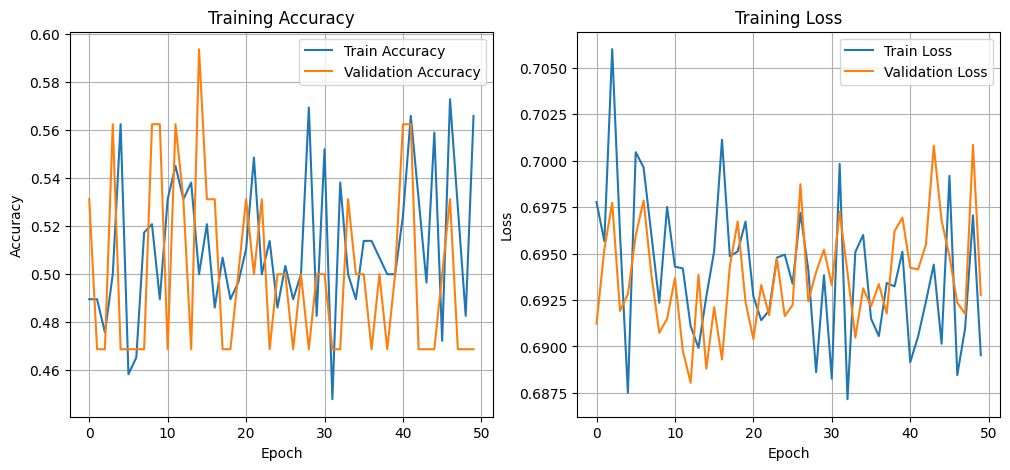


--- Interactive Plot Generated ---
Check the generated plots for signs of overfitting (Validation Loss increasing while Train Loss decreases).


In [66]:
import numpy as np
import pywt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION AND HYPERPARAMETERS ---
# These are the main settings you can interactively change in your notebook.
N_TRIALS = 400       # Total number of simulated EEG trials/samples
N_CHANNELS_EEG = 5   # Number of EEG channels (e.g., Fp1, Fp2, T7, P7, O1)
N_TIME_POINTS = 512  # Number of data points per trial (e.g., 2 seconds at 256Hz)
DWT_WAVELET = 'db4'  # Discrete Wavelet Transform basis function
DWT_LEVEL = 3        # Decomposition level for DWT
EPOCHS = 50          # Number of training epochs
BATCH_SIZE = 32      # Batch size for training
LEARNING_RATE = 0.001

print(f"--- Configuration ---")
print(f"Total Trials: {N_TRIALS}")
print(f"EEG Shape: ({N_CHANNELS_EEG}, {N_TIME_POINTS}) per trial\n")


# --- 2. PHASE 1: DATA SIMULATION (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
# In a real scenario, you would load your files (e.g., from '4_DWT_Features') here.
# We simulate a dataset where each trial is a 5x512 matrix.

print("--- Phase 1: Data Simulation ---")

# Simulate EEG data (400 trials, 5 channels, 512 time points)
# The data values are random noise, simulating the raw EEG signals.
X_simulated_raw = np.random.randn(N_TRIALS, N_CHANNELS_EEG, N_TIME_POINTS)

# Simulate labels (0=Truth, 1=Lie)
Y_labels = np.random.randint(0, 2, N_TRIALS)

# Split into training and testing sets
X_train_raw, X_test_raw, Y_train, Y_test = train_test_split(
    X_simulated_raw, Y_labels, test_size=0.2, random_state=42
)

print(f"Training Data Shape (raw): {X_train_raw.shape}")
print(f"Testing Data Shape (raw): {X_test_raw.shape}")
print(f"Training Labels Shape: {Y_train.shape}\n")


# --- 3. PHASE 2: FEATURE EXTRACTION (DWT) AND RESHAPING ---
# We extract features (statistical properties of DWT coefficients) from each channel.

def extract_dwt_features(raw_data, wavelet, level):
    """
    Applies DWT to each channel and extracts statistical features.
    Output shape for one trial: (N_CHANNELS, N_FEATURES_PER_CHANNEL)
    """
    n_trials, n_channels, _ = raw_data.shape
    all_features = []

    for trial_idx in range(n_trials):
        trial_features = []
        
        for ch_idx in range(n_channels):
            signal = raw_data[trial_idx, ch_idx, :]
            
            # Apply DWT (approximation and detail coefficients)
            coeffs = pywt.wavedec(signal, wavelet, level=level)
            
            channel_features = []
            for c in coeffs:
                # Extract 4 statistical features from each coefficient array
                channel_features.extend([
                    np.mean(c),         # Mean
                    np.std(c),          # Standard Deviation
                    np.max(np.abs(c)),  # Max Absolute Value
                    np.var(c)           # Variance
                ])
            trial_features.append(channel_features)
        
        # trial_features is a list of lists: 5 channels * 10 features each = 50 features per trial
        all_features.append(np.array(trial_features))

    # Resulting shape: (N_trials, N_CHANNELS, N_FEATURES_PER_CHANNEL)
    return np.array(all_features)

print("--- Phase 2: Feature Extraction (DWT) and Reshaping ---")

# 1. Extract Features from Training and Testing Sets
X_train_features = extract_dwt_features(X_train_raw, DWT_WAVELET, DWT_LEVEL)
X_test_features = extract_dwt_features(X_test_raw, DWT_WAVELET, DWT_LEVEL)

# 2. Reshape for CNN-LSTM Input
# The shape is already correct after the extraction function!
# (N_samples, N_time_steps/channels, N_features_per_step)
# X_train_features.shape -> (320, 5, 10)
X_train_reshaped = X_train_features
X_test_reshaped = X_test_features

# Determine the final feature shape for model definition
N_CHANNELS = X_train_reshaped.shape[1]      # 5 channels (time steps for LSTM)
N_FEATURES = X_train_reshaped.shape[2]      # 10 DWT features per channel

print(f"Final Input Shape to Model: ({N_TRIALS*0.8:.0f} samples, {N_CHANNELS} channels, {N_FEATURES} features)")
print(f"X_train_reshaped shape: {X_train_reshaped.shape}\n")


# --- 4. PHASE 3: CNN-LSTM HYBRID MODEL DEFINITION ---

def build_cnnlstm_model(input_shape):
    """Defines the CNN-LSTM hybrid model architecture."""
    model = Sequential()
    
    # INPUT: (5 channels, 10 features)
    
    # 1. 1D Convolutional Layer
    # Looks for spatial patterns within the 10 features of each channel (time step)
    model.add(Conv1D(
        filters=64, 
        kernel_size=3,          # Window of 3 features
        activation='relu', 
        input_shape=input_shape
    ))
    model.add(Dropout(0.3))
    
    # 2. LSTM Layer
    # Processes the sequential output of the Conv1D layer across the 5 channels
    # The LSTM treats the 5 channels as sequential time steps.
    model.add(LSTM(
        units=100, 
        return_sequences=False  # Output only the final state for classification
    ))
    model.add(Dropout(0.3))
    
    # 3. Dense Classifier Head
    model.add(Dense(50, activation='relu'))
    
    # 4. Output Layer (Binary Classification: Truth or Lie)
    model.add(Dense(1, activation='sigmoid')) # Sigmoid for binary classification

    # Compile the model
    optimizer = Adam(learning_rate=LEARNING_RATE)
    model.compile(
        optimizer=optimizer, 
        loss='binary_crossentropy', 
        metrics=['accuracy']
    )
    
    return model

# Build the model and print summary
INPUT_SHAPE = (N_CHANNELS, N_FEATURES)
cnnlstm_model = build_cnnlstm_model(INPUT_SHAPE)
print("--- Phase 3: CNN-LSTM Model Summary ---")
cnnlstm_model.summary()


# --- 5. PHASE 4: TRAINING AND EVALUATION ---

print("\n--- Phase 4: Starting Model Training ---")

# Train the model
history = cnnlstm_model.fit(
    X_train_reshaped, 
    Y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1, # 10% of training data is used for validation
    verbose=1 # Show the progress bar during training
)

print("\n--- Training Complete. Evaluating on Test Set ---")

# 1. Evaluate the model on the unseen test set
loss, accuracy = cnnlstm_model.evaluate(X_test_reshaped, Y_test, verbose=0)
print(f"✅ Test Accuracy: {accuracy*100:.2f}%")

# 2. Generate predictions and report
Y_pred_prob = cnnlstm_model.predict(X_test_reshaped, verbose=0)
Y_pred_class = (Y_pred_prob > 0.5).astype(int) # Convert probabilities > 0.5 to 1 (Lie)

print("\n--- Classification Report ---")
print(classification_report(Y_test, Y_pred_class, target_names=['Truth (0)', 'Lie (1)']))

print("\n--- Confusion Matrix (Actual vs. Predicted) ---")
cm = confusion_matrix(Y_test, Y_pred_class)
print(cm)

# 3. Interactive Element: Plotting the training history
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()
print("\n--- Interactive Plot Generated ---")
print("Check the generated plots for signs of overfitting (Validation Loss increasing while Train Loss decreases).")